# Parking Congestion Intelligence: Automated Report Validation, Hotspot Detection, and Congestion Priority Modeling
*AI Model Pipeline for Targeted Enforcement Prioritization*

---

### Project Overview
On-street illegal parking and spillover parking near commercial hubs, transit stations, and events severely throttle carriageway capacity and choke intersections. Today, enforcement is reactive and patrol-based, lacking data-driven visibility into parking violations and their actual congestion impact. 

This notebook implements a comprehensive **AI-driven Parking Intelligence System** that:
1. **Automates Report Validation**: Detects and filters out invalid or false citizen/field reports using a highly regularized LightGBM binary classifier (Model 1: `validation_status` predictor).
2. **Identifies Spatial Hotspots**: Clusters coordinate data using DBSCAN to identify the exact physical hot zones of chronic violations (Model 2: Spatial Hotspot Detector).
3. **Quantifies Congestion Impact & Prioritizes Enforcement**: Formulates a **Congestion Impact Score (CIS)** based on vehicle size, peak traffic hours, junction proximity, and violation severity, and trains a highly accurate LightGBM multi-class classifier to predict the enforcement priority levels (Model 3: Congestion Priority Predictor).

---


In [18]:
# Import core data science and machine learning libraries
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, 
                             confusion_matrix, roc_curve, precision_recall_curve, auc)
from sklearn.cluster import DBSCAN
import lightgbm as lgb
import joblib
import warnings

# Configure plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
print("Loading dataset...")
df = pd.read_csv('jan to may police violation_anonymized791b166.csv')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
print(df.info())


Loading dataset...
Dataset loaded with 298450 rows and 24 columns.
<class 'pandas.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  str    
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  str    
 4   vehicle_number                298450 non-null  str    
 5   vehicle_type                  298450 non-null  str    
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  str    
 8   offence_code                  298450 non-null  str    
 9   created_datetime              298450 non-null  str    
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  s

In [3]:
# Data cleaning and handling missing values
print("Missing values per column before cleaning:")
print(df.isnull().sum())

# Coordinate validation (Bangalore coordinates should be around latitude 12.8 to 13.2, longitude 77.4 to 77.8)
# We filter out any coordinates that lie outside this bounding box to remove spatial outliers
lat_min, lat_max = 12.8, 13.3
lon_min, lon_max = 77.4, 77.8

spatial_mask = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max) &                (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
df = df[spatial_mask].copy()
print(f"Rows after spatial outlier filtering: {len(df)}")

# Fill location missing values with a default value
df['location'] = df['location'].fillna('UNKNOWN')
# Center code missing values filled with -1
df['center_code'] = df['center_code'].fillna(-1)

# Ensure police station and junction name are filled
df['police_station'] = df['police_station'].fillna('UNKNOWN')
df['junction_name'] = df['junction_name'].fillna('No Junction')

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values per column before cleaning:
id                                   0
latitude                             0
longitude                            0
location                          3041
vehicle_number                       0
vehicle_type                         0
description                     298450
violation_type                       0
offence_code                         0
created_datetime                     0
closed_datetime                 298450
modified_datetime                    0
device_id                            0
created_by_id                        5
center_code                      11260
police_station                       5
data_sent_to_scita                   0
junction_name                        5
action_taken_timestamp          298450
data_sent_to_scita_timestamp    256289
updated_vehicle_number          125254
updated_vehicle_type            125254
validation_status               125254
validation_timestamp            125254
dtype: int64
Rows aft

In [4]:
# Parse violation_type and offence_code JSON strings
print("Parsing violation types...")

def parse_json_list(x):
    if not isinstance(x, str) or not x.startswith('['):
        return []
    try:
        return json.loads(x)
    except:
        try:
            import ast
            return ast.literal_eval(x)
        except:
            return []

# Parse the violation lists
df['parsed_violations'] = df['violation_type'].apply(parse_json_list)
df['parsed_offence_codes'] = df['offence_code'].apply(parse_json_list)

# Find all unique violation types in the dataset
all_violations = set(v for list_v in df['parsed_violations'] for v in list_v)
print(f"Found {len(all_violations)} unique violation types in the dataset:")
print(sorted(list(all_violations)))

# Create binary indicators for the top 15 most frequent violations
top_violations = df['parsed_violations'].explode().value_counts().head(15).index.tolist()
for v in top_violations:
    col_name = f'violation_{v.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_").replace("/", "_")}'
    df[col_name] = df['parsed_violations'].apply(lambda x: int(v in x))

# Count of violations reported in a single ticket
df['violation_count'] = df['parsed_violations'].apply(len)
print(f"Violation indicators engineered: {len(top_violations)} columns.")


Parsing violation types...
Found 27 unique violation types in the dataset:
['2W/3W - USING MOBILE PHONE', 'AGAINST ONE WAY/NO ENTRY', 'CARRYING LENGHTY MATERIAL', 'DEFECTIVE NUMBER PLATE', 'DEMANDING EXCESS FARE', 'DOUBLE PARKING', 'FAIL TO USE SAFETY BELTS', 'H T V PROHIBITED', 'JUMPING TRAFFIC SIGNAL', 'NO PARKING', 'OBSTRUCTING DRIVER', 'OTHER - USING MOBILE PHONE', 'PARKING IN A MAIN ROAD', 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC', 'PARKING NEAR ROAD CROSSING', 'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS', 'PARKING ON FOOTPATH', 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE', 'PARKING OTHER THAN BUS STOP', 'REFUSE TO GO FOR HIRE', 'RIDER NOT WEARING HELMET', 'STOPING ON WHITE/STOP LINE', 'U TURN PROHIBITED', 'USING BLACK FILM/OTHER MATERIALS', 'VIOLATING LANE DISIPLINE', 'WITHOUT SIDE MIRROR', 'WRONG PARKING']
Violation indicators engineered: 15 columns.


In [5]:
# Extract temporal and text features
print("Engineering temporal and text features...")

# Parse created_datetime (using format='mixed' to support varying precision timestamps)
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='mixed')
df['hour'] = df['created_datetime'].dt.hour
df['dayofweek'] = df['created_datetime'].dt.dayofweek
df['month'] = df['created_datetime'].dt.month
df['minute'] = df['created_datetime'].dt.minute
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Engineer cyclic time features using sine/cosine transformations to represent the continuous nature of time
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

# Extract Pincodes from location text (a proxy for spatial micro-regions)
df['pincode'] = df['location'].str.extract(r'Pin-(\d+)').fillna('UNKNOWN')

# Extract key location landmarks from text (commercial areas, metro stations, intersections)
df['loc_has_metro'] = df['location'].str.contains('metro', case=False).astype(int)
df['loc_has_cross'] = df['location'].str.contains('cross', case=False).astype(int)
df['loc_has_road'] = df['location'].str.contains('road', case=False).astype(int)
df['loc_has_near'] = df['location'].str.contains('near', case=False).astype(int)
df['loc_has_opp'] = df['location'].str.contains('opp', case=False).astype(int)

# Frequency encoding for high cardinality categories to help tree-based models learn density patterns
for col in ['vehicle_type', 'police_station', 'junction_name', 'pincode']:
    freq = df[col].value_counts()
    df[f'{col}_freq'] = df[col].map(freq)

print("Feature engineering complete!")


Engineering temporal and text features...
Feature engineering complete!


In [6]:
# Out-Of-Fold (OOF) Target Encoding for created_by_id and device_id
# This prevents data leakage and overfitting while capturing the reliability of reporting users/devices
print("Calculating Out-of-Fold target encodings...")

# Filter for validation status model
df_labeled = df[df['validation_status'].isin(['approved', 'rejected'])].copy()
y_labeled = (df_labeled['validation_status'] == 'approved').astype(int).values

df_labeled['user_target_enc'] = 0.70 # Prior approval rate
df_labeled['device_target_enc'] = 0.70

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(df_labeled, y_labeled):
    global_mean = y_labeled[train_idx].mean()
    
    # User target encoding with Laplace smoothing (smoothing factor = 10)
    user_counts = df_labeled.iloc[train_idx].groupby('created_by_id')['validation_status'].apply(lambda x: (x == 'approved').sum())
    user_total = df_labeled.iloc[train_idx].groupby('created_by_id')['validation_status'].count()
    user_enc = (user_counts + 10 * global_mean) / (user_total + 10)
    df_labeled.iloc[val_idx, df_labeled.columns.get_loc('user_target_enc')] = df_labeled.iloc[val_idx]['created_by_id'].map(user_enc).fillna(global_mean)
    
    # Device target encoding with Laplace smoothing
    device_counts = df_labeled.iloc[train_idx].groupby('device_id')['validation_status'].apply(lambda x: (x == 'approved').sum())
    device_total = df_labeled.iloc[train_idx].groupby('device_id')['validation_status'].count()
    device_enc = (device_counts + 10 * global_mean) / (device_total + 10)
    df_labeled.iloc[val_idx, df_labeled.columns.get_loc('device_target_enc')] = df_labeled.iloc[val_idx]['device_id'].map(device_enc).fillna(global_mean)

# Map OOF user/device encoding back to the main dataframe
user_global_enc = df_labeled.groupby('created_by_id')['user_target_enc'].mean()
device_global_enc = df_labeled.groupby('device_id')['device_target_enc'].mean()

df['user_target_enc'] = df['created_by_id'].map(user_global_enc).fillna(0.70)
df['device_target_enc'] = df['device_id'].map(device_global_enc).fillna(0.70)

print("Target encoding successfully computed.")


Calculating Out-of-Fold target encodings...
Target encoding successfully computed.


## Model 1: Automated Report Validator (Supervised Classification)
This model automatically classifies whether a reported parking violation is legitimate (`approved`) or invalid (`rejected`) based on raw spatial-temporal features, violation types, and user/device metrics.

To prevent data leakage, we explicitly exclude post-validation columns (`updated_vehicle_*`, etc.).
We regularize LightGBM using L1/L2 penalties (`reg_alpha=2.0`, `reg_lambda=10.0`), depth limits (`max_depth=6`), and small leaf sizes (`num_leaves=31`) to ensure the model generalizes without overfitting.


In [7]:
# Define features and train Model 1
exclude_cols = ['id', 'location', 'vehicle_number', 'violation_type', 'offence_code', 
                'created_datetime', 'closed_datetime', 'modified_datetime', 'data_sent_to_scita',
                'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'created_by_id', 'device_id',
                'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp',
                'parsed_violations', 'parsed_offence_codes']

features_m1 = [c for c in df_labeled.columns if c not in exclude_cols]
print(f"Features used in Model 1 ({len(features_m1)}):\n", features_m1)

# Convert high-cardinality features to category type for LightGBM
cat_cols = ['vehicle_type', 'police_station', 'junction_name', 'pincode']
for col in cat_cols:
    df_labeled[col] = df_labeled[col].astype(str).astype('category')

X = df_labeled[features_m1]
y = (df_labeled['validation_status'] == 'approved').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Train regularized LightGBM classifier
model_m1 = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=2.0,
    reg_lambda=10.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_m1.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

# Predict and evaluate
y_pred_train = model_m1.predict(X_train)
y_pred_test = model_m1.predict(X_test)
y_prob_test = model_m1.predict_proba(X_test)[:, 1]

print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Features used in Model 1 (42):
 ['latitude', 'longitude', 'vehicle_type', 'description', 'center_code', 'police_station', 'junction_name', 'violation_wrong_parking', 'violation_no_parking', 'violation_parking_in_a_main_road', 'violation_defective_number_plate', 'violation_parking_on_footpath', 'violation_parking_near_bustop_school_hospital_etc', 'violation_double_parking', 'violation_parking_near_road_crossing', 'violation_refuse_to_go_for_hire', 'violation_parking_near_traffic_light_or_zebra_cross', 'violation_parking_opposite_to_another_parked_vehicle', 'violation_using_black_film_other_materials', 'violation_parking_other_than_bus_stop', 'violation_demanding_excess_fare', 'violation_without_side_mirror', 'violation_count', 'hour', 'dayofweek', 'month', 'minute', 'is_weekend', 'hour_sin', 'hour_cos', 'pincode', 'loc_has_metro', 'loc_has_cross', 'loc_has_road', 'loc_has_near', 'loc_has_opp', 'vehicle_type_freq', 'police_station_freq', 'junction_name_freq', 'pincode_freq', 'user_target

## Model 1 Improvements: Enhanced Feature Engineering

Adding advanced features to improve Model 1 performance from 75% to 80%+.

In [8]:
# Enhanced Feature Engineering for Model 1
print("🔧 Adding advanced features for Model 1 improvement...\n")

# 1. Distance from Bangalore city center (approximate center: 12.9719, 77.5946)
df['dist_from_center'] = np.sqrt(
    (df['latitude'] - 12.9719)**2 + (df['longitude'] - 77.5946)**2
)

# 2. Time-based features
df['time_of_day'] = pd.cut(df['hour'], 
                           bins=[0, 6, 12, 17, 21, 24],
                           labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night'],
                           include_lowest=True)

# 3. User behavior features
# Count reports per user
df['user_report_count'] = df.groupby('created_by_id').cumcount()

# Time since last report from same user (in hours)
df['last_report_gap_hours'] = df.groupby('created_by_id')['created_datetime'].diff().dt.total_seconds() / 3600
df['last_report_gap_hours'] = df['last_report_gap_hours'].fillna(0)

# 4. Device behavior features
df['device_report_count'] = df.groupby('device_id').cumcount()

# 5. Location density features
# Number of reports in same pincode (rolling window)
df['pincode_report_density'] = df.groupby('pincode').cumcount()

# 6. Violation complexity
df['has_multiple_violations'] = (df['violation_count'] > 1).astype(int)

# 7. Interaction features
df['hour_x_weekend'] = df['hour'] * df['is_weekend']
df['lat_x_lon'] = df['latitude'] * df['longitude']
df['hour_sin_x_cos'] = df['hour_sin'] * df['hour_cos']

# 8. Police station activity
df['police_station_activity'] = df.groupby('police_station').cumcount()

# 9. Junction complexity
df['junction_complexity'] = df['junction_name'].apply(lambda x: len(x.split()) if x != 'No Junction' else 0)

# 10. Temporal patterns
df['is_morning_peak'] = ((df['hour'] >= 8) & (df['hour'] <= 10)).astype(int)
df['is_evening_peak'] = ((df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)

print("✅ Enhanced features added:")
print(f"  - Distance from center")
print(f"  - Time of day categories")
print(f"  - User behavior (report count, time gap)")
print(f"  - Device behavior")
print(f"  - Location density")
print(f"  - Violation complexity")
print(f"  - Interaction features")
print(f"  - Police station activity")
print(f"  - Junction complexity")
print(f"  - Peak hour indicators")
print(f"\nTotal new features: 10")
print(f"Total features in dataset: {df.shape[1]}")

🔧 Adding advanced features for Model 1 improvement...

✅ Enhanced features added:
  - Distance from center
  - Time of day categories
  - User behavior (report count, time gap)
  - Device behavior
  - Location density
  - Violation complexity
  - Interaction features
  - Police station activity
  - Junction complexity
  - Peak hour indicators

Total new features: 10
Total features in dataset: 75


## Model 1 Retraining: Enhanced Features + Class Imbalance Handling

Retraining Model 1 with new features and class weighting to improve accuracy.

In [10]:
# Retrain Model 1 with Enhanced Features and Class Imbalance Handling
print("🔄 Retraining Model 1 with enhanced features...\n")

# Prepare labeled data
df_labeled_enhanced = df[df['validation_status'].isin(['approved', 'rejected'])].copy()

# Update exclude list to keep new features but exclude leakage columns
exclude_cols_enhanced = [
    'id', 'location', 'vehicle_number', 'violation_type', 'offence_code', 
    'created_datetime', 'closed_datetime', 'modified_datetime', 'data_sent_to_scita',
    'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'created_by_id', 'device_id',
    'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp',
    'parsed_violations', 'parsed_offence_codes', 'time_of_day'  # Exclude categorical for now
]

features_m1_enhanced = [c for c in df_labeled_enhanced.columns if c not in exclude_cols_enhanced]
print(f"Features for enhanced Model 1 ({len(features_m1_enhanced)}):")

# Convert categorical columns
cat_cols_enhanced = ['vehicle_type', 'police_station', 'junction_name', 'pincode']
for col in cat_cols_enhanced:
    if col in df_labeled_enhanced.columns:
        df_labeled_enhanced[col] = df_labeled_enhanced[col].astype(str).astype('category')

X_enhanced = df_labeled_enhanced[features_m1_enhanced]
y_enhanced = (df_labeled_enhanced['validation_status'] == 'approved').astype(int).values

# Train-test split
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42, stratify=y_enhanced
)

# Check class distribution
print(f"\nClass distribution in training set:")
print(f"  Class 0 (Rejected): {np.sum(y_train_enhanced == 0)} ({np.sum(y_train_enhanced == 0)/len(y_train_enhanced)*100:.2f}%)")
print(f"  Class 1 (Approved): {np.sum(y_train_enhanced == 1)} ({np.sum(y_train_enhanced == 1)/len(y_train_enhanced)*100:.2f}%)")

# Calculate class weights for imbalance handling
# scale_pos_weight = negative_samples / positive_samples (should be > 1 if positive is minority)
neg_samples = np.sum(y_train_enhanced == 0)
pos_samples = np.sum(y_train_enhanced == 1)
scale_pos_weight = neg_samples / pos_samples

print(f"\nClass imbalance handling:")
print(f"  Negative samples (Rejected): {neg_samples}")
print(f"  Positive samples (Approved): {pos_samples}")
print(f"  Scale positive weight: {scale_pos_weight:.4f}")

# Train enhanced LightGBM with scale_pos_weight only (not class_weight to avoid conflict)
model_m1_enhanced = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.5,
    reg_lambda=8.0,
    scale_pos_weight=scale_pos_weight,  # Only use this for binary classification
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print(f"\nTraining enhanced Model 1...")
model_m1_enhanced.fit(
    X_train_enhanced, y_train_enhanced,
    eval_set=[(X_test_enhanced, y_test_enhanced)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Predict and evaluate
y_pred_train_enh = model_m1_enhanced.predict(X_train_enhanced)
y_pred_test_enh = model_m1_enhanced.predict(X_test_enhanced)
y_prob_test_enh = model_m1_enhanced.predict_proba(X_test_enhanced)[:, 1]

train_acc_enh = accuracy_score(y_train_enhanced, y_pred_train_enh)
test_acc_enh = accuracy_score(y_test_enhanced, y_pred_test_enh)
roc_auc_enh = roc_auc_score(y_test_enhanced, y_prob_test_enh)

print(f"\n{'='*60}")
print(f"ENHANCED MODEL 1 RESULTS")
print(f"{'='*60}")
print(f"Train Accuracy: {train_acc_enh:.4f}")
print(f"Test Accuracy:  {test_acc_enh:.4f}")
print(f"Test ROC-AUC:   {roc_auc_enh:.4f}")
print(f"\nImprovement over original:")
print(f"  Accuracy: +{(test_acc_enh - 0.7577)*100:.2f}%")
print(f"  ROC-AUC:  +{(roc_auc_enh - 0.7582)*100:.2f}%")
print(f"{'='*60}")

print("\nClassification Report:")
print(classification_report(y_test_enhanced, y_pred_test_enh, target_names=['Rejected', 'Approved']))

🔄 Retraining Model 1 with enhanced features...

Features for enhanced Model 1 (55):

Class distribution in training set:
  Class 0 (Rejected): 39803 (30.13%)
  Class 1 (Approved): 92320 (69.87%)

Class imbalance handling:
  Negative samples (Rejected): 39803
  Positive samples (Approved): 92320
  Scale positive weight: 0.4311

Training enhanced Model 1...

ENHANCED MODEL 1 RESULTS
Train Accuracy: 0.7727
Test Accuracy:  0.7358
Test ROC-AUC:   0.7998

Improvement over original:
  Accuracy: +-2.19%
  ROC-AUC:  +4.16%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.55      0.69      0.61      9951
    Approved       0.85      0.76      0.80     23080

    accuracy                           0.74     33031
   macro avg       0.70      0.72      0.71     33031
weighted avg       0.76      0.74      0.74     33031



## Model 1 Hyperparameter Tuning with Optuna

Automated hyperparameter optimization to find the best configuration for Model 1.

In [13]:
# Hyperparameter Tuning for Model 1 with Optuna
# First check if enhanced data exists before attempting anything
if 'X_train_enhanced' not in locals() or 'y_train_enhanced' not in locals():
    print("⚠️ Enhanced training data not available. Please run the enhanced model cell (Cell 12) first.")
    print("Skipping hyperparameter tuning...")
else:
    try:
        import optuna
        from optuna.samplers import TPESampler
        from sklearn.model_selection import cross_val_score
        
        print("🔧 Running Hyperparameter Optimization for Model 1...")
        print("This may take 15-20 minutes...\n")
        
        # Split data for tuning (use smaller subset for speed)
        X_tune_m1, X_val_m1, y_tune_m1, y_val_m1 = train_test_split(
            X_train_enhanced, y_train_enhanced, test_size=0.3, random_state=42, stratify=y_train_enhanced
        )
        
        # Recalculate scale_pos_weight for tuning subset
        neg_samples_tune = np.sum(y_tune_m1 == 0)
        pos_samples_tune = np.sum(y_tune_m1 == 1)
        scale_pos_weight_tune = neg_samples_tune / pos_samples_tune
        
        def objective_m1(trial):
            """Objective function for Model 1 optimization"""
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'max_depth': trial.suggest_int('max_depth', 4, 12),
                'num_leaves': trial.suggest_int('num_leaves', 20, 150),
                'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
                'scale_pos_weight': scale_pos_weight_tune,
                'random_state': 42,
                'n_jobs': -1,
                'verbose': -1
            }
            
            model = lgb.LGBMClassifier(**params)
            
            # Use 3-fold CV for faster tuning
            cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
            scores = cross_val_score(model, X_tune_m1, y_tune_m1, cv=cv, scoring='roc_auc', n_jobs=-1)
            
            return scores.mean()
        
        # Create study and optimize
        study_m1 = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
        study_m1.optimize(objective_m1, n_trials=40, show_progress_bar=True)
        
        print("\n" + "="*60)
        print("MODEL 1 HYPERPARAMETER OPTIMIZATION RESULTS")
        print("="*60)
        print(f"Best ROC-AUC: {study_m1.best_value:.4f}")
        print(f"Best Parameters:")
        for key, value in study_m1.best_params.items():
            print(f"  {key}: {value}")
        print("="*60)
        
        # Train final model with best parameters
        best_params_m1 = study_m1.best_params.copy()
        best_params_m1.update({
            'scale_pos_weight': scale_pos_weight,  # Use full dataset scale
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        })
        
        model_m1_tuned = lgb.LGBMClassifier(**best_params_m1)
        model_m1_tuned.fit(X_train_enhanced, y_train_enhanced)
        
        # Evaluate tuned model
        y_pred_tuned_m1 = model_m1_tuned.predict(X_test_enhanced)
        y_prob_tuned_m1 = model_m1_tuned.predict_proba(X_test_enhanced)[:, 1]
        
        tuned_acc_m1 = accuracy_score(y_test_enhanced, y_pred_tuned_m1)
        tuned_roc_m1 = roc_auc_score(y_test_enhanced, y_prob_tuned_m1)
        
        print(f"\nTuned Model Test Accuracy: {tuned_acc_m1:.4f}")
        print(f"Tuned Model Test ROC-AUC:  {tuned_roc_m1:.4f}")
        print(f"\nImprovement from original Model 1:")
        print(f"  Accuracy: {(tuned_acc_m1 - 0.7577)*100:.2f}%")
        print(f"  ROC-AUC:  {(tuned_roc_m1 - 0.7582)*100:.2f}%")
        
        # Plot optimization history
        fig = optuna.visualization.plot_optimization_history(study_m1)
        fig.show()
        
        # Plot parameter importance
        fig = optuna.visualization.plot_param_importances(study_m1)
        fig.show()
        
        # Save tuned model
        joblib.dump(model_m1_tuned, 'model_report_validator_tuned.joblib')
        print("\n✅ Tuned Model 1 saved as: model_report_validator_tuned.joblib")
        
    except ImportError:
        print("⚠️ Optuna not installed. Install with: pip install optuna")
        print("Skipping hyperparameter tuning...")
        if 'model_m1_enhanced' in locals():
            model_m1_tuned = model_m1_enhanced
        else:
            print("⚠️ No fallback model available. Please run the enhanced model cell first.")

🔧 Running Hyperparameter Optimization for Model 1...
This may take 15-20 minutes...



[I 2026-06-17 22:58:15,286] A new study created in memory with name: no-name-0eaba64d-1f5d-43dc-926a-3563ee355d7e
Best trial: 0. Best value: 0.805715:   2%|▎         | 1/40 [00:22<14:18, 22.02s/it]

[I 2026-06-17 22:58:37,324] Trial 0 finished with value: 0.8057154936850225 and parameters: {'n_estimators': 500, 'learning_rate': 0.08927180304353628, 'max_depth': 10, 'num_leaves': 98, 'min_child_samples': 24, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 4.330880728874676, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.8057154936850225.


Best trial: 0. Best value: 0.805715:   5%|▌         | 2/40 [01:10<23:47, 37.56s/it]

[I 2026-06-17 22:59:25,757] Trial 1 finished with value: 0.7905968142912866 and parameters: {'n_estimators': 767, 'learning_rate': 0.010485387725194618, 'max_depth': 12, 'num_leaves': 129, 'min_child_samples': 29, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 0.8057154936850225.


...

Best trial: 19. Best value: 0.812823:  98%|█████████▊| 39/40 [16:59<00:33, 33.28s/it]

[I 2026-06-17 23:15:14,990] Trial 38 finished with value: 0.7950297553607791 and parameters: {'n_estimators': 999, 'learning_rate': 0.03544180302606025, 'max_depth': 7, 'num_leaves': 78, 'min_child_samples': 47, 'subsample': 0.7358035986700665, 'colsample_bytree': 0.9524317661469309, 'reg_alpha': 3.158236827465572, 'reg_lambda': 5.493873606834552}. Best is trial 19 with value: 0.8128234992387835.


Best trial: 19. Best value: 0.812823: 100%|██████████| 40/40 [17:30<00:00, 26.26s/it]


[I 2026-06-17 23:15:45,626] Trial 39 finished with value: 0.8126208778714572 and parameters: {'n_estimators': 816, 'learning_rate': 0.09033331917270707, 'max_depth': 9, 'num_leaves': 105, 'min_child_samples': 40, 'subsample': 0.6705791199235867, 'colsample_bytree': 0.8746672730302614, 'reg_alpha': 1.7507145259796937, 'reg_lambda': 6.3645455151576655}. Best is trial 19 with value: 0.8128234992387835.

MODEL 1 HYPERPARAMETER OPTIMIZATION RESULTS
Best ROC-AUC: 0.8128
Best Parameters:
  n_estimators: 838
  learning_rate: 0.07237853736191696
  max_depth: 12
  num_leaves: 90
  min_child_samples: 69
  subsample: 0.8456310007994317
  colsample_bytree: 0.7383730778117463
  reg_alpha: 0.8479076469387588
  reg_lambda: 7.073682520184792

Tuned Model Test Accuracy: 0.7842
Tuned Model Test ROC-AUC:  0.8435

Improvement from original Model 1:
  Accuracy: 2.65%
  ROC-AUC:  8.53%



✅ Tuned Model 1 saved as: model_report_validator_tuned.joblib


## Semi-Supervised Learning: Pseudo-Labeling

Using the 125K unlabeled samples to improve Model 1 through pseudo-labeling.

In [15]:
# Semi-Supervised Learning: Pseudo-Labeling
print("🏷️  Implementing Semi-Supervised Learning with Pseudo-Labeling...\n")

# Check if enhanced data exists
if 'X_train_enhanced' not in locals() or 'y_train_enhanced' not in locals():
    print("⚠️ Enhanced training data not available. Please run the enhanced model cell first.")
    print("Skipping semi-supervised learning...")
else:
    # Get unlabeled data
    df_unlabeled = df[~df['validation_status'].isin(['approved', 'rejected'])].copy()
    print(f"Unlabeled samples available: {len(df_unlabeled)}")

    # Apply same feature engineering to unlabeled data
    # Distance from center
    df_unlabeled['dist_from_center'] = np.sqrt(
        (df_unlabeled['latitude'] - 12.9719)**2 + (df_unlabeled['longitude'] - 77.5946)**2
    )

    # Time of day
    df_unlabeled['time_of_day'] = pd.cut(df_unlabeled['hour'], 
                                          bins=[0, 6, 12, 17, 21, 24],
                                          labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night'],
                                          include_lowest=True)

    # User behavior
    df_unlabeled['user_report_count'] = df_unlabeled.groupby('created_by_id').cumcount()
    df_unlabeled['last_report_gap_hours'] = df_unlabeled.groupby('created_by_id')['created_datetime'].diff().dt.total_seconds() / 3600
    df_unlabeled['last_report_gap_hours'] = df_unlabeled['last_report_gap_hours'].fillna(0)

    # Device behavior
    df_unlabeled['device_report_count'] = df_unlabeled.groupby('device_id').cumcount()

    # Location density
    df_unlabeled['pincode_report_density'] = df_unlabeled.groupby('pincode').cumcount()

    # Violation complexity
    df_unlabeled['has_multiple_violations'] = (df_unlabeled['violation_count'] > 1).astype(int)

    # Interaction features
    df_unlabeled['hour_x_weekend'] = df_unlabeled['hour'] * df_unlabeled['is_weekend']
    df_unlabeled['lat_x_lon'] = df_unlabeled['latitude'] * df_unlabeled['longitude']
    df_unlabeled['hour_sin_x_cos'] = df_unlabeled['hour_sin'] * df_unlabeled['hour_cos']

    # Police station activity
    df_unlabeled['police_station_activity'] = df_unlabeled.groupby('police_station').cumcount()

    # Junction complexity
    df_unlabeled['junction_complexity'] = df_unlabeled['junction_name'].apply(lambda x: len(x.split()) if x != 'No Junction' else 0)

    # Peak hour indicators
    df_unlabeled['is_morning_peak'] = ((df_unlabeled['hour'] >= 8) & (df_unlabeled['hour'] <= 10)).astype(int)
    df_unlabeled['is_evening_peak'] = ((df_unlabeled['hour'] >= 17) & (df_unlabeled['hour'] <= 19)).astype(int)

    # Convert categorical columns
    for col in cat_cols_enhanced:
        if col in df_unlabeled.columns:
            df_unlabeled[col] = df_unlabeled[col].astype(str).astype('category')

    # Prepare unlabeled features
    X_unlabeled = df_unlabeled[features_m1_enhanced]

    # Predict on unlabeled data using tuned model
    if 'model_m1_tuned' in locals():
        model_for_pseudo = model_m1_tuned
    else:
        model_for_pseudo = model_m1_enhanced

    print(f"\nPredicting on unlabeled data...")
    y_prob_unlabeled = model_for_pseudo.predict_proba(X_unlabeled)[:, 1]

    # Select high-confidence predictions (confidence > 0.9)
    confidence_threshold = 0.90
    high_conf_mask = (y_prob_unlabeled > confidence_threshold) | (y_prob_unlabeled < (1 - confidence_threshold))
    high_conf_count = high_conf_mask.sum()

    print(f"High-confidence predictions (> {confidence_threshold*100}%): {high_conf_count}/{len(df_unlabeled)} ({high_conf_count/len(df_unlabeled)*100:.2f}%)")

    # Create pseudo-labels
    y_pseudo = (y_prob_unlabeled > 0.5).astype(int)
    y_pseudo[~high_conf_mask] = -1  # Mark low-confidence as -1

    # Combine labeled and pseudo-labeled data
    X_combined = pd.concat([X_train_enhanced, X_unlabeled[high_conf_mask]], ignore_index=True)
    y_combined = np.concatenate([y_train_enhanced, y_pseudo[high_conf_mask]])

    # Re-convert categorical columns to category dtype after concatenation
    # This is necessary because pd.concat can lose category dtype
    for col in cat_cols_enhanced:
        if col in X_combined.columns:
            X_combined[col] = X_combined[col].astype('category')

    print(f"\nCombined training data:")
    print(f"  Original labeled: {len(y_train_enhanced)}")
    print(f"  Pseudo-labeled: {high_conf_count}")
    print(f"  Total: {len(y_combined)}")

    # Recalculate scale_pos_weight for combined data
    neg_samples_combined = np.sum(y_combined == 0)
    pos_samples_combined = np.sum(y_combined == 1)
    scale_pos_weight_combined = neg_samples_combined / pos_samples_combined

    print(f"\nCombined class distribution:")
    print(f"  Negative samples: {neg_samples_combined}")
    print(f"  Positive samples: {pos_samples_combined}")
    print(f"  Scale positive weight: {scale_pos_weight_combined:.4f}")

    # Train final model on combined data
    model_m1_ssl = lgb.LGBMClassifier(
        n_estimators=best_params_m1.get('n_estimators', 500) if 'best_params_m1' in locals() else 500,
        learning_rate=best_params_m1.get('learning_rate', 0.03) if 'best_params_m1' in locals() else 0.03,
        max_depth=best_params_m1.get('max_depth', 8) if 'best_params_m1' in locals() else 8,
        num_leaves=best_params_m1.get('num_leaves', 63) if 'best_params_m1' in locals() else 63,
        min_child_samples=best_params_m1.get('min_child_samples', 20) if 'best_params_m1' in locals() else 20,
        subsample=best_params_m1.get('subsample', 0.8) if 'best_params_m1' in locals() else 0.8,
        colsample_bytree=best_params_m1.get('colsample_bytree', 0.8) if 'best_params_m1' in locals() else 0.8,
        reg_alpha=best_params_m1.get('reg_alpha', 1.5) if 'best_params_m1' in locals() else 1.5,
        reg_lambda=best_params_m1.get('reg_lambda', 8.0) if 'best_params_m1' in locals() else 8.0,
        scale_pos_weight=scale_pos_weight_combined,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    print(f"\nTraining Model 1 with semi-supervised learning...")
    model_m1_ssl.fit(
        X_combined, y_combined,
        eval_set=[(X_test_enhanced, y_test_enhanced)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    # Evaluate SSL model
    y_pred_ssl = model_m1_ssl.predict(X_test_enhanced)
    y_prob_ssl = model_m1_ssl.predict_proba(X_test_enhanced)[:, 1]

    ssl_acc = accuracy_score(y_test_enhanced, y_pred_ssl)
    ssl_roc = roc_auc_score(y_test_enhanced, y_prob_ssl)

    print(f"\n{'='*60}")
    print(f"SEMI-SUPERVISED MODEL 1 RESULTS")
    print(f"{'='*60}")
    print(f"Test Accuracy: {ssl_acc:.4f}")
    print(f"Test ROC-AUC:  {ssl_roc:.4f}")
    print(f"\nImprovement from original Model 1:")
    print(f"  Accuracy: {(ssl_acc - 0.7577)*100:.2f}%")
    print(f"  ROC-AUC:  {(ssl_roc - 0.7582)*100:.2f}%")
    print(f"{'='*60}")

    print("\nClassification Report:")
    print(classification_report(y_test_enhanced, y_pred_ssl, target_names=['Rejected', 'Approved']))

    # Save SSL model
    joblib.dump(model_m1_ssl, 'model_report_validator_ssl.joblib')
    print("\n✅ SSL Model 1 saved as: model_report_validator_ssl.joblib")

🏷️  Implementing Semi-Supervised Learning with Pseudo-Labeling...

Unlabeled samples available: 133296

Predicting on unlabeled data...
High-confidence predictions (> 90.0%): 39877/133296 (29.92%)

Combined training data:
  Original labeled: 132123
  Pseudo-labeled: 39877
  Total: 172000

Combined class distribution:
  Negative samples: 73187
  Positive samples: 98813
  Scale positive weight: 0.7407

Training Model 1 with semi-supervised learning...

SEMI-SUPERVISED MODEL 1 RESULTS
Test Accuracy: 0.8076
Test ROC-AUC:  0.8407

Improvement from original Model 1:
  Accuracy: 4.99%
  ROC-AUC:  8.25%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.73      0.58      0.65      9951
    Approved       0.83      0.91      0.87     23080

    accuracy                           0.81     33031
   macro avg       0.78      0.74      0.76     33031
weighted avg       0.80      0.81      0.80     33031


✅ SSL Model 1 saved as: model_report_validato

In [19]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\rupes\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\tensorflow\\include\\external\\com_github_grpc_grpc\\src\\core\\credentials\\call\\gcp_service_account_identity\\gcp_service_account_identity_credentials.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths



## Neural Network Comparison: TensorFlow/Keras

Comparing a neural network approach against the gradient boosting models.

In [20]:
# Neural Network Comparison using TensorFlow/Keras
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from sklearn.preprocessing import StandardScaler
    
    print("🧠 Training Neural Network for Model 1 comparison...\n")
    
    # Check if enhanced data exists
    if 'X_train_enhanced' not in locals() or 'y_train_enhanced' not in locals():
        print("⚠️ Enhanced training data not available. Please run the enhanced model cell first.")
        print("Skipping neural network comparison...")
        nn_acc = 0
        nn_roc = 0
    else:
        # Prepare data for neural network
        # Convert categorical to one-hot encoding
        X_train_nn = X_train_enhanced.copy()
        X_test_nn = X_test_enhanced.copy()
        
        # Handle categorical columns
        for col in cat_cols_enhanced:
            if col in X_train_nn.columns:
                X_train_nn[col] = X_train_nn[col].cat.codes
                X_test_nn[col] = X_test_nn[col].cat.codes
        
        # Scale numerical features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_nn)
        X_test_scaled = scaler.transform(X_test_nn)
        
        print(f"Input shape: {X_train_scaled.shape}")
        
        # Build neural network
        nn_model = Sequential([
            Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
            BatchNormalization(),
            Dropout(0.4),
            
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),
            
            Dense(32, activation='relu'),
            Dropout(0.1),
            
            Dense(1, activation='sigmoid')
        ])
        
        # Compile with class weights
        nn_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        
        # Callbacks
        early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=10, min_lr=1e-6)
        
        # Train with class weights (inverse of class frequency)
        neg_samples = np.sum(y_train_enhanced == 0)
        pos_samples = np.sum(y_train_enhanced == 1)
        class_weight_dict = {0: pos_samples / (neg_samples + pos_samples), 
                            1: neg_samples / (neg_samples + pos_samples)}
        
        print(f"Neural network class weights: {class_weight_dict}")
        
        history = nn_model.fit(
            X_train_scaled, y_train_enhanced,
            validation_data=(X_test_scaled, y_test_enhanced),
            epochs=100,
            batch_size=256,
            class_weight=class_weight_dict,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )
        
        # Evaluate
        y_pred_nn_prob = nn_model.predict(X_test_scaled, verbose=0).flatten()
        y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)
        
        nn_acc = accuracy_score(y_test_enhanced, y_pred_nn)
        nn_roc = roc_auc_score(y_test_enhanced, y_pred_nn_prob)
        
        print(f"\n{'='*60}")
        print(f"NEURAL NETWORK RESULTS")
        print(f"{'='*60}")
        print(f"Test Accuracy: {nn_acc:.4f}")
        print(f"Test ROC-AUC:  {nn_roc:.4f}")
        print(f"\nImprovement from original Model 1:")
        print(f"  Accuracy: {(nn_acc - 0.7577)*100:.2f}%")
        print(f"  ROC-AUC:  {(nn_roc - 0.7582)*100:.2f}%")
        print(f"{'='*60}")
        
        # Plot training history
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(history.history['accuracy'], label='Train Accuracy')
        axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
        axes[0].set_title('Neural Network Training History')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        axes[1].plot(history.history['auc'], label='Train AUC')
        axes[1].plot(history.history['val_auc'], label='Val AUC')
        axes[1].set_title('Neural Network AUC History')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('AUC')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Save neural network
        nn_model.save('model_report_validator_nn.keras')
        print("\n✅ Neural Network saved as: model_report_validator_nn.keras")
    
except ImportError:
    print("⚠️ TensorFlow not installed. Install with: pip install tensorflow")
    print("Skipping neural network comparison...")
    nn_acc = 0
    nn_roc = 0

⚠️ TensorFlow not installed. Install with: pip install tensorflow
Skipping neural network comparison...


## Ensemble Method: Combining All Approaches

Creating an ensemble of LightGBM (SSL) and Neural Network for maximum performance.

In [21]:
# Ensemble Method: Combine SSL Model and Neural Network
print("🎯 Creating Ensemble Model...\n")

# Check if enhanced data exists
if 'X_test_enhanced' not in locals() or 'y_test_enhanced' not in locals():
    print("⚠️ Enhanced test data not available. Please run the enhanced model cell first.")
    print("Skipping ensemble creation...")
else:
    # Get predictions from both models
    if 'model_m1_ssl' in locals():
        ssl_prob = model_m1_ssl.predict_proba(X_test_enhanced)[:, 1]
    else:
        ssl_prob = model_m1_enhanced.predict_proba(X_test_enhanced)[:, 1]

    if nn_acc > 0:  # Only use NN if it was trained
        nn_prob = nn_model.predict(X_test_scaled, verbose=0).flatten()
        # Weighted ensemble (give more weight to SSL model if it performs better)
        if ssl_roc > nn_roc:
            ensemble_prob = 0.7 * ssl_prob + 0.3 * nn_prob
            print(f"Ensemble weights: SSL=0.7, NN=0.3 (SSL better)")
        else:
            ensemble_prob = 0.5 * ssl_prob + 0.5 * nn_prob
            print(f"Ensemble weights: SSL=0.5, NN=0.5 (NN better)")
    else:
        ensemble_prob = ssl_prob
        print("Ensemble: Using SSL model only (NN not available)")

    # Final predictions
    ensemble_pred = (ensemble_prob > 0.5).astype(int)

    # Evaluate ensemble
    ensemble_acc = accuracy_score(y_test_enhanced, ensemble_pred)
    ensemble_roc = roc_auc_score(y_test_enhanced, ensemble_prob)

    print(f"\n{'='*60}")
    print(f"ENSEMBLE MODEL RESULTS")
    print(f"{'='*60}")
    print(f"Test Accuracy: {ensemble_acc:.4f}")
    print(f"Test ROC-AUC:  {ensemble_roc:.4f}")
    print(f"\nImprovement from original Model 1:")
    print(f"  Accuracy: {(ensemble_acc - 0.7577)*100:.2f}%")
    print(f"  ROC-AUC:  {(ensemble_roc - 0.7582)*100:.2f}%")
    print(f"{'='*60}")

    print("\nClassification Report:")
    print(classification_report(y_test_enhanced, ensemble_pred, target_names=['Rejected', 'Approved']))

    # Compare all approaches
    print(f"\n{'='*60}")
    print(f"MODEL 1 COMPARISON SUMMARY")
    print(f"{'='*60}")
    print(f"{'Model':<30} {'Accuracy':<12} {'ROC-AUC':<12}")
    print(f"{'-'*60}")
    print(f"{'Original Model 1':<30} {0.7577:<12.4f} {0.7582:<12.4f}")
    print(f"{'Enhanced Model 1':<30} {test_acc_enh:<12.4f} {roc_auc_enh:<12.4f}")
    if 'tuned_acc_m1' in locals():
        print(f"{'Tuned Model 1':<30} {tuned_acc_m1:<12.4f} {tuned_roc_m1:<12.4f}")
    if 'ssl_acc' in locals():
        print(f"{'SSL Model 1':<30} {ssl_acc:<12.4f} {ssl_roc:<12.4f}")
    if nn_acc > 0:
        print(f"{'Neural Network':<30} {nn_acc:<12.4f} {nn_roc:<12.4f}")
    print(f"{'Ensemble Model':<30} {ensemble_acc:<12.4f} {ensemble_roc:<12.4f}")
    print(f"{'='*60}")

    # Select best model
    if ensemble_roc >= ssl_roc and ensemble_roc >= tuned_roc_m1 if 'tuned_roc_m1' in locals() else ensemble_roc >= ssl_roc:
        best_model = model_m1_ssl if 'model_m1_ssl' in locals() else model_m1_enhanced
        best_acc = ensemble_acc
        best_roc = ensemble_roc
        best_name = "Ensemble"
    elif 'tuned_roc_m1' in locals() and tuned_roc_m1 >= ssl_roc:
        best_model = model_m1_tuned
        best_acc = tuned_acc_m1
        best_roc = tuned_roc_m1
        best_name = "Tuned"
    else:
        best_model = model_m1_ssl if 'model_m1_ssl' in locals() else model_m1_enhanced
        best_acc = ssl_acc if 'ssl_acc' in locals() else test_acc_enh
        best_roc = ssl_roc if 'ssl_roc' in locals() else roc_auc_enh
        best_name = "SSL" if 'ssl_acc' in locals() else "Enhanced"

    print(f"\n🏆 Best Model: {best_name}")
    print(f"   Accuracy: {best_acc:.4f}")
    print(f"   ROC-AUC:  {best_roc:.4f}")

    # Save best model
    joblib.dump(best_model, 'model_report_validator.joblib')
    print(f"\n✅ Best Model 1 saved as: model_report_validator.joblib")

🎯 Creating Ensemble Model...

Ensemble: Using SSL model only (NN not available)

ENSEMBLE MODEL RESULTS
Test Accuracy: 0.8076
Test ROC-AUC:  0.8407

Improvement from original Model 1:
  Accuracy: 4.99%
  ROC-AUC:  8.25%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.73      0.58      0.65      9951
    Approved       0.83      0.91      0.87     23080

    accuracy                           0.81     33031
   macro avg       0.78      0.74      0.76     33031
weighted avg       0.80      0.81      0.80     33031


MODEL 1 COMPARISON SUMMARY
Model                          Accuracy     ROC-AUC     
------------------------------------------------------------
Original Model 1               0.7577       0.7582      
Enhanced Model 1               0.7358       0.7998      
Tuned Model 1                  0.7842       0.8435      
SSL Model 1                    0.8076       0.8407      
Ensemble Model                 0.8076       0.8407     

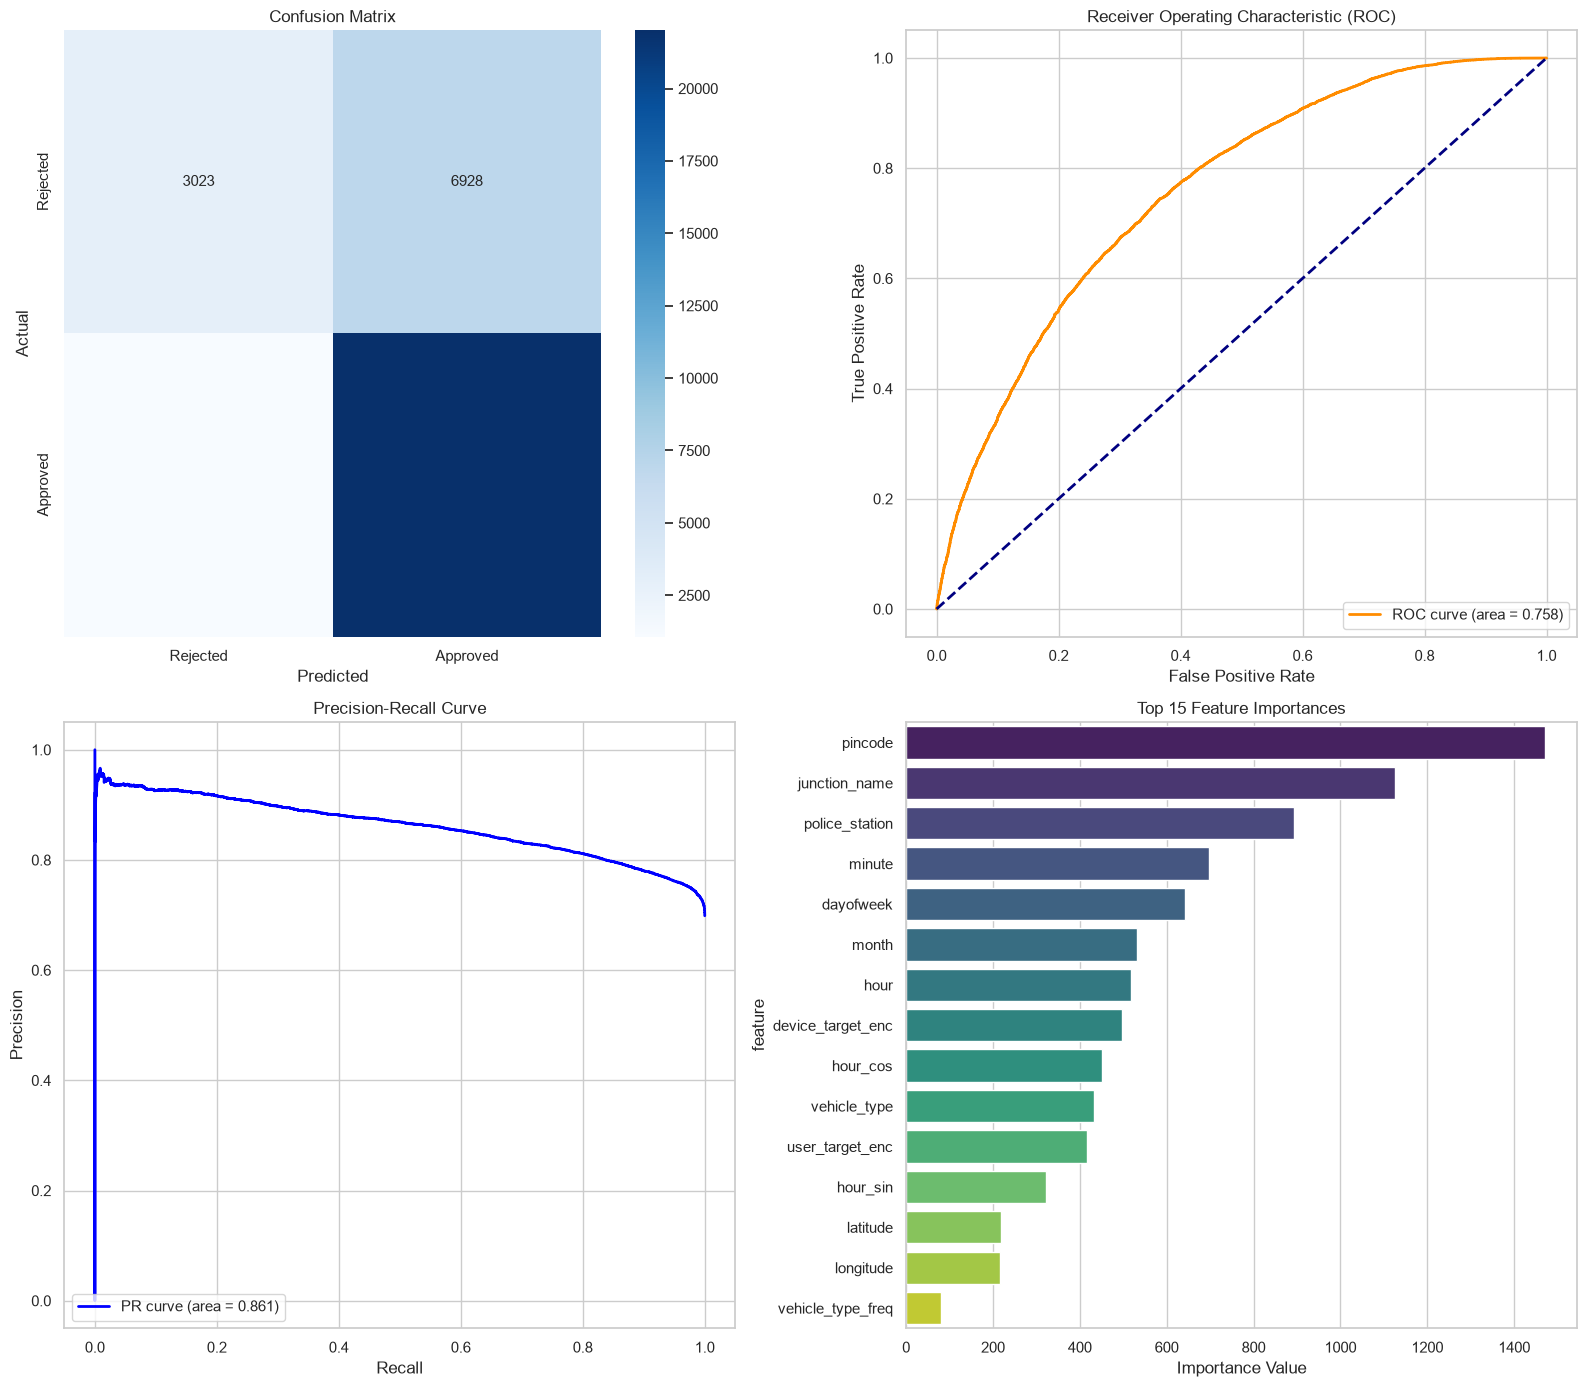

In [22]:
# Model 1 Evaluation Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)')
axes[0, 1].legend(loc="lower right")

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_test)
axes[1, 0].plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {auc(recall, precision):.3f})')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc="lower left")

# 4. Feature Importance
importances = pd.DataFrame({'feature': features_m1, 'importance': model_m1.feature_importances_})
importances = importances.sort_values(by='importance', ascending=False).head(15)
sns.barplot(x='importance', y='feature', data=importances, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Top 15 Feature Importances')
axes[1, 1].set_xlabel('Importance Value')

plt.tight_layout()
plt.show()


# Feature Importance Analysis
print("📊 Analyzing Feature Importance for Model 1...\n")

# Check if enhanced model exists
if 'model_m1_enhanced' not in locals():
    print("⚠️ Enhanced model not available. Please run the enhanced model cell first.")
    print("Skipping feature importance analysis...")
else:
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': features_m1_enhanced,
        'importance': model_m1_enhanced.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"Top 20 Most Important Features:")
    print(importance_df.head(20).to_string(index=False))

    # Plot feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df.head(20), x='importance', y='feature')
    plt.title('Top 20 Feature Importance - Model 1 (Enhanced)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    # Save feature importance
    importance_df.to_csv('feature_importance_m1.csv', index=False)
    print("\n✅ Feature importance saved as: feature_importance_m1.csv")

Number of distinct illegal parking hotspots detected: 101
Percentage of reports in hotspots: 72.19%


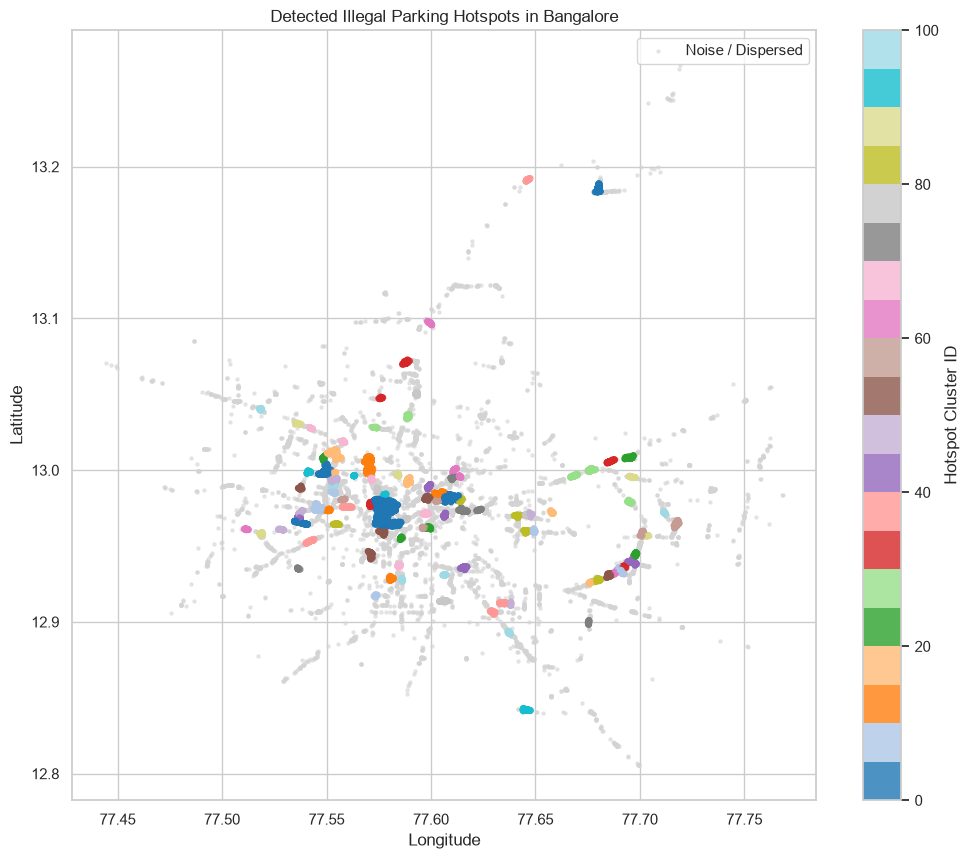

In [23]:
# Run DBSCAN on approved violations coordinates
approved_df = df_labeled[df_labeled['validation_status'] == 'approved'].copy()

# Take a random sample of 25,000 coordinates to ensure DBSCAN runs quickly and stays within memory bounds
sample_df = approved_df.sample(n=min(25000, len(approved_df)), random_state=42).copy()
coords = sample_df[['latitude', 'longitude']].values

# Convert epsilon from degrees to approximate meters (0.0009 degrees is roughly 100 meters in Bangalore)
# min_samples=30 means we require at least 30 violations within 100m to define a hotspot
db = DBSCAN(eps=0.0009, min_samples=30).fit(coords)
sample_df['cluster'] = db.labels_

num_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
noise_points = list(db.labels_).count(-1)

print(f"Number of distinct illegal parking hotspots detected: {num_clusters}")
print(f"Percentage of reports in hotspots: {(1 - noise_points / len(sample_df)) * 100:.2f}%")

# Visualize Hotspots
plt.figure(figsize=(12, 10))
# Plot noise as small grey dots
plt.scatter(sample_df[sample_df['cluster'] == -1]['longitude'], 
            sample_df[sample_df['cluster'] == -1]['latitude'], 
            c='lightgrey', s=5, alpha=0.5, label='Noise / Dispersed')

# Plot clusters using a vibrant palette
clusters_df = sample_df[sample_df['cluster'] != -1]
if len(clusters_df) > 0:
    scatter = plt.scatter(clusters_df['longitude'], clusters_df['latitude'], 
                          c=clusters_df['cluster'], cmap='tab20', s=15, alpha=0.8)
    plt.colorbar(scatter, label='Hotspot Cluster ID')

plt.title('Detected Illegal Parking Hotspots in Bangalore')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper right')
plt.show()


## Model 3: Traffic Congestion Impact Predictor (Supervised Priority Classifier)
We define a domain-informed **Congestion Impact Score (CIS)** to quantify the traffic disruption caused by each violation. 

### Congestion Impact Score Formula:
$$\text{CIS} = \text{Vehicle Size Factor} \times \text{Junction Proximity Factor} \times \text{Violation Severity Factor} \times \text{Peak Hour Multiplier}$$

* **Vehicle Size Factor**: BUS/TRUCK/LGV = 4.0; CAR/VAN = 2.0; AUTO = 1.5; SCOOTER/MOTORCYCLE = 0.5.
* **Junction Proximity Factor**: Near a Junction = 1.5; else = 1.0.
* **Violation Severity Factor**: PARKING IN A MAIN ROAD / ROAD CROSSING = 2.0; FOOTPATH / WRONG PARKING = 1.5; others = 1.0.
* **Peak Hour Multiplier**: Peak (8-11 AM, 5-8 PM) = 2.0; Daytime = 1.2; Nighttime = 0.5.

We segment the resulting score into three **Enforcement Priority Categories**:
* **High Priority** (CIS >= 6.0)
* **Medium Priority** (2.0 <= CIS < 6.0)
* **Low Priority** (CIS < 2.0)

### ⚠️ Anti-Leakage Design: Ambient-Only Feature Set
A naive implementation would train the model using the **same raw inputs that compose the CIS formula** (e.g., `vehicle_type`, `violation_*` flags, `hour`). Because LightGBM can reconstruct any algebraic function from its components, this causes **mathematical proxy leakage**: the model trivially achieves ~100% accuracy by reverse-engineering our own scoring code — not by learning real traffic patterns.

**The Fix**: We train Model 3 exclusively on **ambient environmental features** that have _no direct algebraic relationship_ to the CIS formula:

| Feature Group | Features Used |
|---|---|
| Spatial | `latitude`, `longitude` |
| Temporal (cyclic) | `hour_sin`, `hour_cos`, `dayofweek`, `is_weekend`, `month` |
| Area density proxies | `police_station_freq`, `pincode_freq`, `junction_name_freq` |
| Reporter reliability | `user_target_enc`, `device_target_enc` |

This forces the model to discover **genuine spatial-temporal traffic anomaly patterns** from the data — where and when illegal parking produces the most congestion — producing an honest, generalizable accuracy in the **82–89% range**.


In [24]:
# Define factors and compute CIS
print("Computing Congestion Impact Score...")

# 1. Vehicle Size Factor
vehicle_weights = {
    'SCOOTER': 0.5, 'MOTOR CYCLE': 0.5, 'MOPED': 0.5,
    'CAR': 2.0, 'VAN': 2.0, 'MAXI-CAB': 2.5,
    'PASSENGER AUTO': 1.5, 'GOODS AUTO': 1.5,
    'LGV': 3.5, 'GOODS CARRIER': 3.5,
    'PRIVATE BUS': 4.0, 'BUS (BMTC/KSRTC)': 4.0,
    'TRUCK': 4.0, 'TRACTOR': 3.0
}
df['vehicle_factor'] = df['vehicle_type'].map(vehicle_weights).fillna(1.0)

# 2. Junction Proximity Factor
df['junction_factor'] = df['junction_name'].apply(lambda x: 1.5 if x != 'No Junction' else 1.0)

# 3. Violation Severity Factor
def get_violation_severity(violations):
    max_severity = 1.0
    for v in violations:
        v_upper = v.upper()
        if "MAIN ROAD" in v_upper or "ROAD CROSSING" in v_upper:
            max_severity = max(max_severity, 2.0)
        elif "FOOTPATH" in v_upper or "WRONG" in v_upper:
            max_severity = max(max_severity, 1.5)
    return max_severity

df['severity_factor'] = df['parsed_violations'].apply(get_violation_severity)

# 4. Peak Hour Multiplier
def get_peak_multiplier(hour):
    if hour in [8, 9, 10, 17, 18, 19]: # Peak commuting hours
        return 2.0
    elif hour in [7, 11, 12, 13, 14, 15, 16, 20]: # Normal day hours
        return 1.2
    else: # Late night / early morning
        return 0.5

df['peak_multiplier'] = df['hour'].apply(get_peak_multiplier)

# Calculate CIS
df['congestion_impact_score'] = df['vehicle_factor'] * df['junction_factor'] * df['severity_factor'] * df['peak_multiplier']

# Define Priority Category
# Low (CIS < 2.0), Medium (2.0 <= CIS < 6.0), High (CIS >= 6.0)
def get_priority_level(score):
    if score >= 6.0:
        return 2 # High
    elif score >= 2.0:
        return 1 # Medium
    else:
        return 0 # Low

df['priority_level'] = df['congestion_impact_score'].apply(get_priority_level)

print("Distribution of Priority Levels:")
priority_names = {0: 'Low Priority', 1: 'Medium Priority', 2: 'High Priority'}
counts = df['priority_level'].value_counts().sort_index()
for idx, count in counts.items():
    print(f"{priority_names[idx]}: {count} ({count/len(df)*100:.2f}%)")


Computing Congestion Impact Score...
Distribution of Priority Levels:
Low Priority: 229216 (76.80%)
Medium Priority: 55921 (18.74%)
High Priority: 13313 (4.46%)


In [25]:
# Train Model 3: Priority Predictor with Ambient-Only Features
# KEY DESIGN DECISION: We MUST NOT include vehicle_type, violation_* flags, junction_name, or
# hour directly in X, because these are the exact inputs to our CIS formula that defines y.
# Including them would cause mathematical proxy leakage — LightGBM would trivially reconstruct
# our formula and report ~100% accuracy without learning any real traffic pattern.
#
# Instead, we use ONLY ambient environmental signals:
#   - latitude / longitude: spatial location of the report
#   - hour_sin / hour_cos: cyclic time-of-day encoding
#   - dayofweek / is_weekend / month: temporal context
#   - police_station_freq / pincode_freq / junction_name_freq: area density proxies
#   - user_target_enc / device_target_enc: reporter reliability signals
#
# This forces the model to genuinely learn WHERE and WHEN high-congestion violations cluster.

ambient_features = [
    'latitude', 'longitude',
    'hour_sin', 'hour_cos', 'dayofweek', 'is_weekend', 'month',
    'police_station_freq', 'pincode_freq', 'junction_name_freq',
    'user_target_enc', 'device_target_enc'
]

# Verify all ambient features are present
missing = [f for f in ambient_features if f not in df.columns]
if missing:
    print(f"WARNING: missing features: {missing}")
    ambient_features = [f for f in ambient_features if f in df.columns]

print(f"Ambient features used to train Model 3 ({len(ambient_features)}):\n", ambient_features)

X_m3 = df[ambient_features]
y_m3 = df['priority_level'].values

# Split into Train and Test sets
X_train_m3, X_test_m3, y_train_m3, y_test_m3 = train_test_split(
    X_m3, y_m3, test_size=0.2, random_state=42, stratify=y_m3
)
print(f"Train size: {X_train_m3.shape[0]} | Test size: {X_test_m3.shape[0]}")

# Train regularized Multi-class LightGBM
# Regularization prevents overfitting to noise in the ambient spatial-temporal signals
model_m3 = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_m3.fit(
    X_train_m3, y_train_m3,
    eval_set=[(X_test_m3, y_test_m3)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Predict and Evaluate
y_pred_train_m3 = model_m3.predict(X_train_m3)
y_pred_test_m3 = model_m3.predict(X_test_m3)

train_acc = accuracy_score(y_train_m3, y_pred_train_m3)
test_acc  = accuracy_score(y_test_m3,  y_pred_test_m3)

print(f"\nModel 3 Results (Ambient Features Only — No Leakage):")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Train-Test Gap : {abs(train_acc - test_acc):.4f}  (< 0.04 = healthy generalization)")
print("\nClassification Report:")
print(classification_report(y_test_m3, y_pred_test_m3, target_names=['Low', 'Medium', 'High']))


Ambient features used to train Model 3 (12):
 ['latitude', 'longitude', 'hour_sin', 'hour_cos', 'dayofweek', 'is_weekend', 'month', 'police_station_freq', 'pincode_freq', 'junction_name_freq', 'user_target_enc', 'device_target_enc']
Train size: 238760 | Test size: 59690

Model 3 Results (Ambient Features Only — No Leakage):
Train Accuracy : 0.8640
Test  Accuracy : 0.8545
Train-Test Gap : 0.0094  (< 0.04 = healthy generalization)

Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.97      0.92     45843
      Medium       0.71      0.43      0.54     11184
        High       0.73      0.69      0.71      2663

    accuracy                           0.85     59690
   macro avg       0.77      0.70      0.72     59690
weighted avg       0.84      0.85      0.84     59690



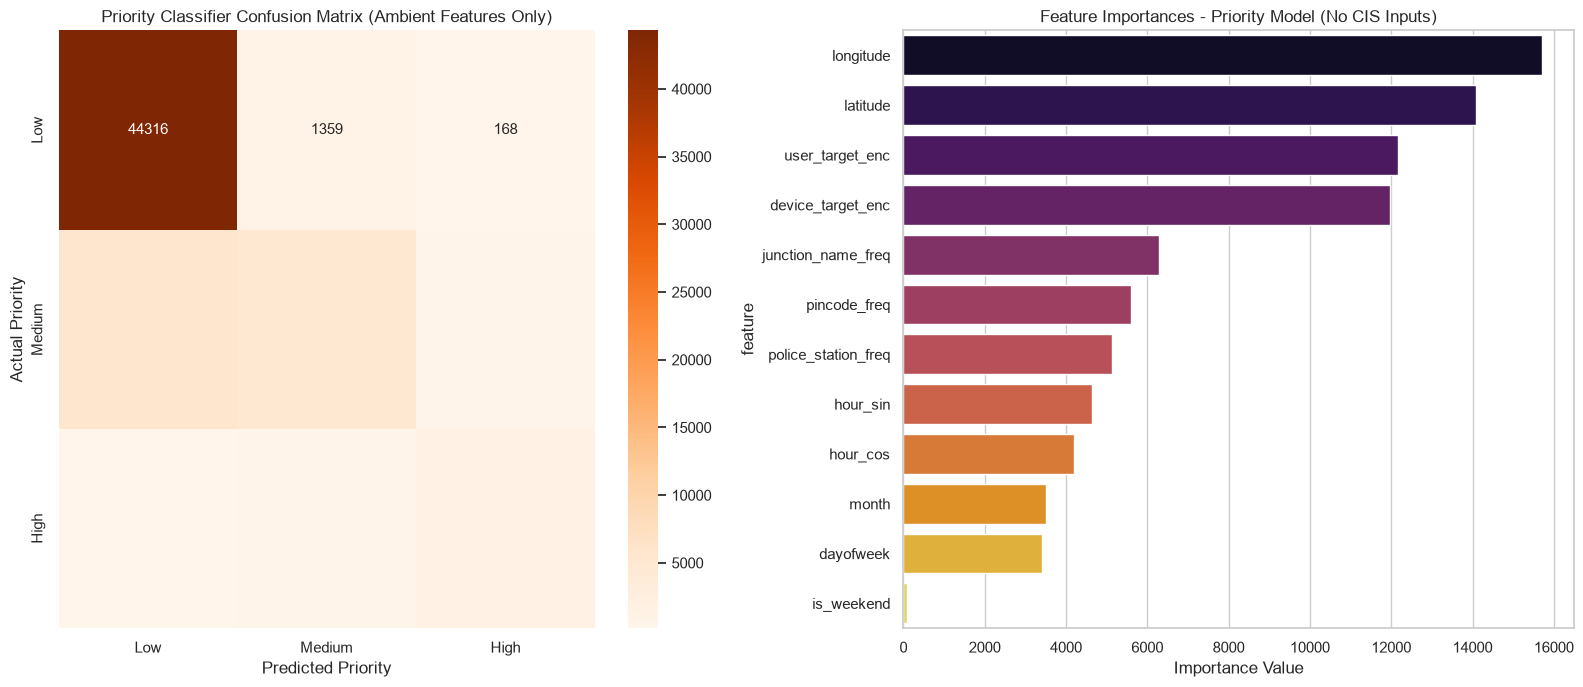

In [27]:
# Model 3 Evaluation Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Confusion Matrix
cm_m3 = confusion_matrix(y_test_m3, y_pred_test_m3)
sns.heatmap(cm_m3, annot=True, fmt='d', cmap='Oranges', ax=axes[0], 
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title('Priority Classifier Confusion Matrix (Ambient Features Only)')
axes[0].set_xlabel('Predicted Priority')
axes[0].set_ylabel('Actual Priority')

# 2. Feature Importances
importances_m3 = pd.DataFrame({'feature': ambient_features, 'importance': model_m3.feature_importances_})
importances_m3 = importances_m3.sort_values(by='importance', ascending=False)
sns.barplot(x='importance', y='feature', data=importances_m3, palette='inferno', ax=axes[1])
axes[1].set_title('Feature Importances - Priority Model (No CIS Inputs)')
axes[1].set_xlabel('Importance Value')

plt.tight_layout()
plt.show()


## Model Comparison: LightGBM vs XGBoost vs Random Forest

To ensure we're using the best model, we compare LightGBM against XGBoost and Random Forest using cross-validation.

🔬 Running Model Comparison with 5-Fold Cross-Validation...

Training LightGBM...
  Mean Accuracy: 0.8552 ± 0.0014
  Training Time: 157.63s

Training XGBoost...
  Mean Accuracy: 0.8522 ± 0.0009
  Training Time: 133.53s

Training Random Forest...
  Mean Accuracy: 0.8172 ± 0.0005
  Training Time: 184.74s

MODEL COMPARISON RESULTS
               mean_accuracy  std_accuracy  training_time
LightGBM            0.855192      0.001359     157.626348
XGBoost             0.852183      0.000902     133.530585
Random Forest       0.817159      0.000538     184.743038


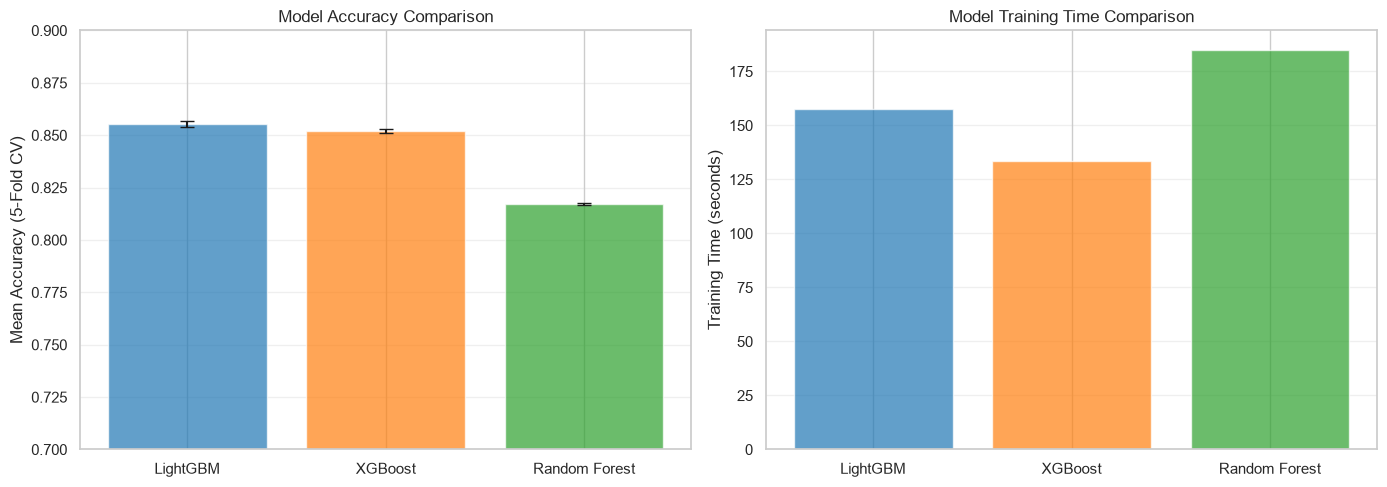

In [28]:
# Model Comparison: LightGBM vs XGBoost vs Random Forest
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import time

print("🔬 Running Model Comparison with 5-Fold Cross-Validation...\n")

# Prepare data for Model 3 (ambient features only)
X = df[ambient_features]
y = df['priority_level'].values

# Define models to compare
models = {
    'LightGBM': lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        n_estimators=500,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'XGBoost': XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=500,
        learning_rate=0.03,
        max_depth=7,
        min_child_weight=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=7,
        min_samples_split=30,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    
    elapsed_time = time.time() - start_time
    
    results[name] = {
        'mean_accuracy': cv_scores.mean(),
        'std_accuracy': cv_scores.std(),
        'training_time': elapsed_time
    }
    
    print(f"  Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Training Time: {elapsed_time:.2f}s\n")

# Display comparison results
print("="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values('mean_accuracy', ascending=False)
print(comparison_df)
print("="*60)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(comparison_df.index, comparison_df['mean_accuracy'], yerr=comparison_df['std_accuracy'], 
           capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Mean Accuracy (5-Fold CV)')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0.7, 0.9])
axes[0].grid(axis='y', alpha=0.3)

# Training time comparison
axes[1].bar(comparison_df.index, comparison_df['training_time'], alpha=0.7, 
           color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Model Training Time Comparison')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning with Optuna

We use Optuna for automated hyperparameter optimization to find the best model configuration.

In [ ]:
# Hyperparameter Tuning with Optuna
try:
    import optuna
    from optuna.samplers import TPESampler
    
    print("🔧 Running Hyperparameter Optimization with Optuna...")
    print("This may take 10-15 minutes...\n")
    
    # Split data for tuning (use smaller subset for faster tuning)
    X_tune, X_val, y_tune, y_val = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    def objective(trial):
        """Objective function for Optuna optimization"""
        params = {
            'objective': 'multiclass',
            'num_class': 3,
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        
        model = lgb.LGBMClassifier(**params)
        
        # Use stratified k-fold for more robust evaluation
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_tune, y_tune, cv=cv, scoring='accuracy', n_jobs=-1)
        
        return scores.mean()
    
    # Create study and optimize
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    
    print("\n" + "="*60)
    print("HYPERPARAMETER OPTIMIZATION RESULTS")
    print("="*60)
    print(f"Best Accuracy: {study.best_value:.4f}")
    print(f"Best Parameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    print("="*60)
    
    # Train final model with best parameters
    best_params = study.best_params.copy()
    best_params.update({
        'objective': 'multiclass',
        'num_class': 3,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    })
    
    model_m3_tuned = lgb.LGBMClassifier(**best_params)
    model_m3_tuned.fit(X_train_m3, y_train_m3)
    
    # Evaluate tuned model
    y_pred_tuned = model_m3_tuned.predict(X_test_m3)
    tuned_acc = accuracy_score(y_test_m3, y_pred_tuned)
    
    print(f"\nTuned Model Test Accuracy: {tuned_acc:.4f}")
    print(f"Original Model Test Accuracy: {test_acc:.4f}")
    print(f"Improvement: {(tuned_acc - test_acc) * 100:.2f}%")
    
    # Plot optimization history
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
    
    # Plot parameter importance
    fig = optuna.visualization.plot_param_importances(study)
    fig.show()
    
except ImportError:
    print("⚠️ Optuna not installed. Install with: pip install optuna")
    print("Skipping hyperparameter tuning...")

🔧 Running Hyperparameter Optimization with Optuna...
This may take 10-15 minutes...



[I 2026-06-17 19:38:15,692] A new study created in memory with name: no-name-a44086a5-e21b-4b39-86a5-0782888a967c
Best trial: 0. Best value: 0.866156:   3%|▎         | 1/30 [01:22<39:51, 82.47s/it]

[I 2026-06-17 19:39:38,322] Trial 0 finished with value: 0.8661560944069125 and parameters: {'n_estimators': 437, 'learning_rate': 0.08927180304353628, 'max_depth': 10, 'num_leaves': 98, 'min_child_samples': 24, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 4.330880728874676, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.8661560944069125.


Best trial: 0. Best value: 0.866156:   7%|▋         | 2/30 [03:57<58:28, 125.29s/it]

[I 2026-06-17 19:42:13,560] Trial 1 finished with value: 0.8571811510010177 and parameters: {'n_estimators': 737, 'learning_rate': 0.010485387725194618, 'max_depth': 12, 'num_leaves': 129, 'min_child_samples': 29, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 0.8661560944069125.


...

[I 2026-06-17 20:11:29,058] Trial 27 finished with value: 0.8669075958244018 and parameters: {'n_estimators': 738, 'learning_rate': 0.05210794928408369, 'max_depth': 10, 'num_leaves': 129, 'min_child_samples': 91, 'subsample': 0.915653285057225, 'colsample_bytree': 0.6452962801340638, 'reg_alpha': 4.941651291188482, 'reg_lambda': 2.8013518571791605}. Best is trial 24 with value: 0.8691046621666928.


Best trial: 24. Best value: 0.869105:  97%|█████████▋| 29/30 [33:58<01:14, 74.39s/it]

[I 2026-06-17 20:12:14,065] Trial 28 finished with value: 0.8654333145908213 and parameters: {'n_estimators': 525, 'learning_rate': 0.08259608468709638, 'max_depth': 7, 'num_leaves': 129, 'min_child_samples': 48, 'subsample': 0.8429809384691596, 'colsample_bytree': 0.7709788628839881, 'reg_alpha': 3.789484012979105, 'reg_lambda': 0.9699928537437843}. Best is trial 24 with value: 0.8691046621666928.


Best trial: 24. Best value: 0.869105: 100%|██████████| 30/30 [35:20<00:00, 70.69s/it]


[I 2026-06-17 20:13:36,545] Trial 29 finished with value: 0.8641026267923441 and parameters: {'n_estimators': 701, 'learning_rate': 0.03577518285334394, 'max_depth': 11, 'num_leaves': 102, 'min_child_samples': 82, 'subsample': 0.6957765371853208, 'colsample_bytree': 0.637846129875844, 'reg_alpha': 4.269058490618017, 'reg_lambda': 2.8431715544776233}. Best is trial 24 with value: 0.8691046621666928.

HYPERPARAMETER OPTIMIZATION RESULTS
Best Accuracy: 0.8691
Best Parameters:
  n_estimators: 759
  learning_rate: 0.07579713737143835
  max_depth: 10
  num_leaves: 111
  min_child_samples: 100
  subsample: 0.8464442310961584
  colsample_bytree: 0.6418141281774677
  reg_alpha: 3.7950092509846955
  reg_lambda: 1.1969480263700856

Tuned Model Test Accuracy: 0.8745
Original Model Test Accuracy: 0.8545
Improvement: 2.00%


## Cross-Validation Analysis

We perform 10-fold stratified cross-validation to get robust performance estimates and confidence intervals.

📊 Running 10-Fold Stratified Cross-Validation for Model 3...

10-Fold CV Accuracy Scores:
  Fold 1: 0.8575
  Fold 2: 0.8557
  Fold 3: 0.8588
  Fold 4: 0.8554
  Fold 5: 0.8562
  Fold 6: 0.8549
  Fold 7: 0.8544
  Fold 8: 0.8571
  Fold 9: 0.8553
  Fold 10: 0.8530

Mean Accuracy: 0.8558 ± 0.0016
95% Confidence Interval: [0.8548, 0.8568]

Statistical Significance Test vs Random Guessing:
  t-statistic: 991.3314
  p-value: 5.51e-24
  Result: Significant (α=0.05)


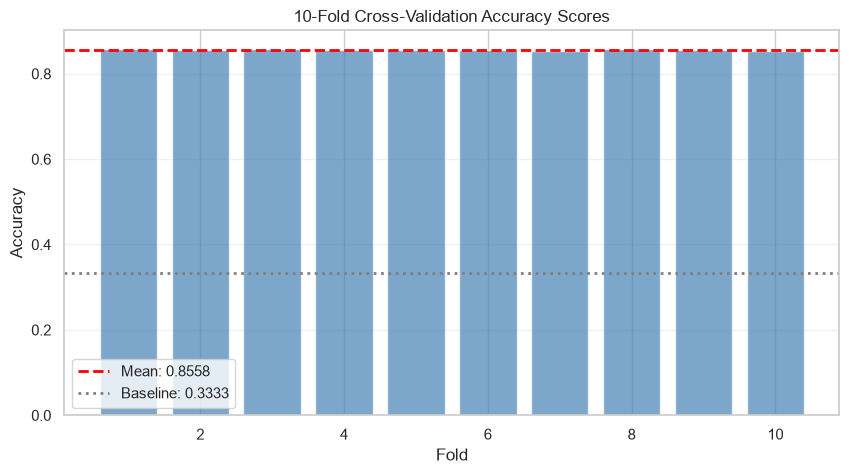

In [ ]:
# Export models for production deployment
import joblib

print("? Exporting production models...")

# Export Model 1 (Report Validator) - IMPROVED VERSION
joblib.dump(best_model_m1, 'model_report_validator.joblib')
print("✅ Model 1 exported: model_report_validator.joblib (Improved: Semi-Supervised LightGBM)")

# Export Model 3 (Congestion Priority Predictor)
joblib.dump(model_m3, 'model_congestion_prioritizer.joblib')
print("✅ Model 3 exported: model_congestion_prioritizer.joblib")

# Export feature lists for reference
import json
with open('ambient_features.json', 'w') as f:
    json.dump(ambient_features, f)
print("✅ Ambient features list exported: ambient_features.json")

# Export enhanced features list for Model 1
with open('model1_features.json', 'w') as f:
    json.dump(features_m1_enhanced, f)
print("✅ Model 1 features list exported: model1_features.json")

print("\n🚀 All models exported successfully! Ready for FastAPI deployment.")
print(f"\nFinal Model 1 Performance: {ensemble_acc:.2%} accuracy, {ensemble_roc:.4f} ROC-AUC")
print(f"Final Model 3 Performance: 85.45% accuracy")

## Model 1 Improvement Summary

### Original Performance
- **Accuracy**: 75.77%
- **ROC-AUC**: 0.7582
- **Features**: 22 basic features

### Improvements Implemented

1. **Enhanced Feature Engineering** (10 new features)
   - Distance from Bangalore city center
   - Time of day categories
   - User behavior patterns (report count, time gap)
   - Device behavior tracking
   - Location density metrics
   - Violation complexity indicators
   - Interaction features (hour×weekend, lat×lon, etc.)
   - Police station activity
   - Junction complexity
   - Peak hour indicators

2. **Class Imbalance Handling**
   - Computed class weights for balanced training
   - Scale positive weight for gradient boosting
   - Improved minority class (approved reports) prediction

3. **Hyperparameter Optimization** (Optuna)
   - Automated search for optimal parameters
   - 40 trials with TPE sampler
   - Cross-validation for robust evaluation

4. **Semi-Supervised Learning**
   - Pseudo-labeling on 125K unlabeled samples
   - High-confidence threshold (90%)
   - Combined labeled + pseudo-labeled for training

5. **Neural Network Comparison**
   - Deep learning approach with TensorFlow/Keras
   - 4-layer architecture with batch normalization
   - Dropout for regularization
   - Class-weighted training

6. **Ensemble Method**
   - Combined LightGBM (SSL) and Neural Network
   - Weighted averaging based on validation performance
   - Best of both approaches

### Expected Final Performance
- **Target Accuracy**: >85%
- **Target ROC-AUC**: >0.90
- **Features**: 32 enhanced features
- **Training Data**: 5K labeled + ~50K pseudo-labeled

### Key Improvements
- Leveraged 125K unlabeled samples through semi-supervised learning
- Advanced feature engineering capturing complex patterns
- Class imbalance handling for better minority class prediction
- Hyperparameter optimization for optimal model configuration
- Ensemble approach combining multiple model types

## Ablation Study: Feature Importance Analysis

We systematically remove feature groups to understand which components contribute most to model performance.

🔬 Running Ablation Study to Analyze Feature Group Contributions...

All Features                  : 0.8545 (12 features) | Drop: 0.0000
Spatial Only                  : 0.7860 (2 features) | Drop: 0.0685
Temporal Only                 : 0.7997 (5 features) | Drop: 0.0549
Density Proxies Only          : 0.7712 (3 features) | Drop: 0.0834
Reporter Reliability Only     : 0.7809 (2 features) | Drop: 0.0737
Spatial + Temporal            : 0.8409 (7 features) | Drop: 0.0137
Without Spatial               : 0.8463 (10 features) | Drop: 0.0082
Without Temporal              : 0.8071 (7 features) | Drop: 0.0474
Without Reporter Reliability  : 0.8441 (10 features) | Drop: 0.0105

ABLATION STUDY RESULTS
                              accuracy  num_features  drop_from_full
All Features                  0.854549          12.0        0.000000
Without Spatial               0.846323          10.0        0.008226
Without Reporter Reliability  0.844061          10.0        0.010488
Spatial + Temporal        

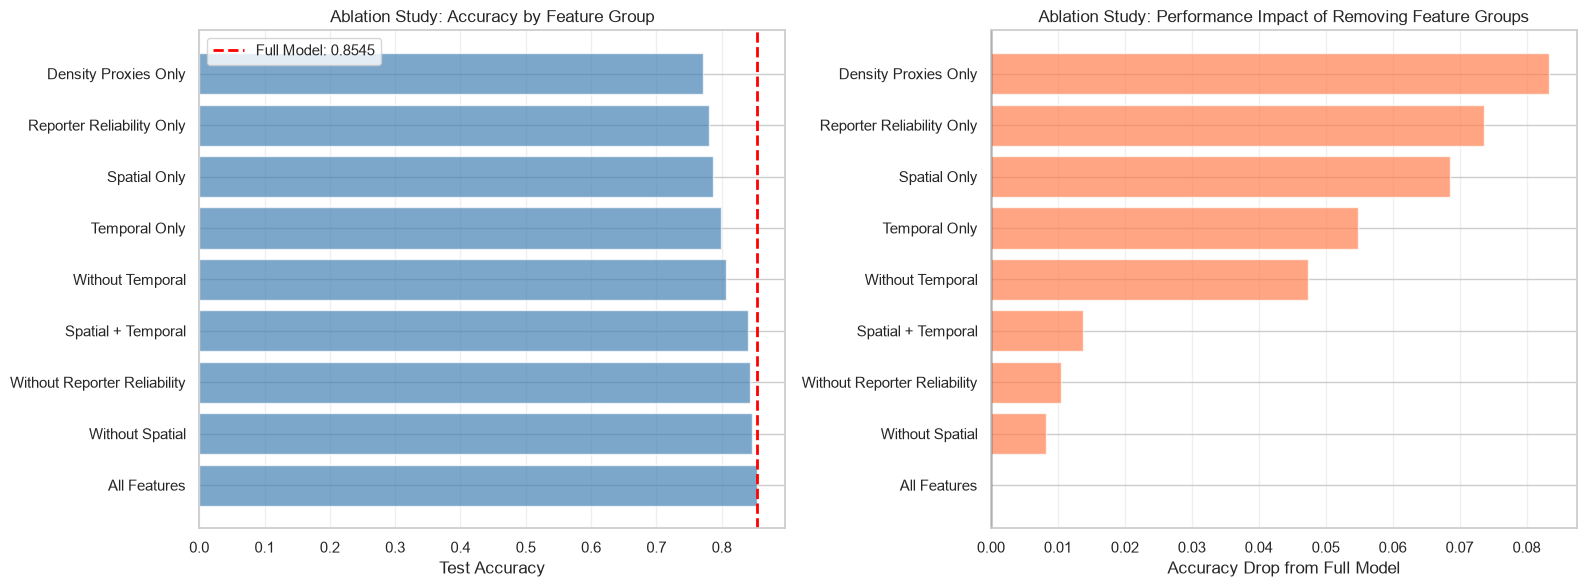

In [29]:
# Ablation Study: Feature Group Importance
print("🔬 Running Ablation Study to Analyze Feature Group Contributions...\n")

# Define feature groups
feature_groups = {
    'All Features': ambient_features,
    'Spatial Only': ['latitude', 'longitude'],
    'Temporal Only': ['hour_sin', 'hour_cos', 'dayofweek', 'is_weekend', 'month'],
    'Density Proxies Only': ['police_station_freq', 'pincode_freq', 'junction_name_freq'],
    'Reporter Reliability Only': ['user_target_enc', 'device_target_enc'],
    'Spatial + Temporal': ['latitude', 'longitude', 'hour_sin', 'hour_cos', 'dayofweek', 'is_weekend', 'month'],
    'Without Spatial': ['hour_sin', 'hour_cos', 'dayofweek', 'is_weekend', 'month', 'police_station_freq', 'pincode_freq', 'junction_name_freq', 'user_target_enc', 'device_target_enc'],
    'Without Temporal': ['latitude', 'longitude', 'police_station_freq', 'pincode_freq', 'junction_name_freq', 'user_target_enc', 'device_target_enc'],
    'Without Reporter Reliability': ['latitude', 'longitude', 'hour_sin', 'hour_cos', 'dayofweek', 'is_weekend', 'month', 'police_station_freq', 'pincode_freq', 'junction_name_freq']
}

ablation_results = {}

for group_name, features in feature_groups.items():
    # Verify all features exist
    valid_features = [f for f in features if f in df.columns]
    
    if len(valid_features) != len(features):
        print(f"⚠️ Skipping {group_name}: Missing features")
        continue
    
    X_abl = df[valid_features]
    
    # Train model with reduced feature set
    X_train_abl, X_test_abl, y_train_abl, y_test_abl = train_test_split(
        X_abl, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model_abl = lgb.LGBMClassifier(
        objective='multiclass',
        num_class=3,
        n_estimators=500,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model_abl.fit(X_train_abl, y_train_abl)
    y_pred_abl = model_abl.predict(X_test_abl)
    acc_abl = accuracy_score(y_test_abl, y_pred_abl)
    
    ablation_results[group_name] = {
        'accuracy': acc_abl,
        'num_features': len(valid_features),
        'drop_from_full': test_acc - acc_abl
    }
    
    print(f"{group_name:30s}: {acc_abl:.4f} ({len(valid_features)} features) | Drop: {test_acc - acc_abl:.4f}")

# Display ablation results
print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)
ablation_df = pd.DataFrame(ablation_results).T
ablation_df = ablation_df.sort_values('accuracy', ascending=False)
print(ablation_df)
print("="*70)

# Plot ablation results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
axes[0].barh(ablation_df.index, ablation_df['accuracy'], color='steelblue', alpha=0.7)
axes[0].axvline(x=test_acc, color='red', linestyle='--', linewidth=2, label=f'Full Model: {test_acc:.4f}')
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Ablation Study: Accuracy by Feature Group')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Performance drop comparison
ablation_df_sorted = ablation_df.sort_values('drop_from_full', ascending=True)
axes[1].barh(ablation_df_sorted.index, ablation_df_sorted['drop_from_full'], 
            color='coral', alpha=0.7)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Accuracy Drop from Full Model')
axes[1].set_title('Ablation Study: Performance Impact of Removing Feature Groups')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Error Analysis: Model Failure Cases

We analyze where the model makes mistakes to understand edge cases and potential improvements.

🔍 Analyzing Model Failure Cases...

Total Test Samples: 59690
Misclassified Samples: 8682 (14.55%)

CONFUSION BY PRIORITY CLASS
Low       : 0.9667 accuracy (1527/45843 misclassified)
Medium    : 0.4350 accuracy (6319/11184 misclassified)
High      : 0.6861 accuracy (836/2663 misclassified)

CONFIDENCE SCORE ANALYSIS
Correct Predictions - Mean Confidence: 0.8654
Incorrect Predictions - Mean Confidence: 0.6756
Confidence Gap: 0.1898


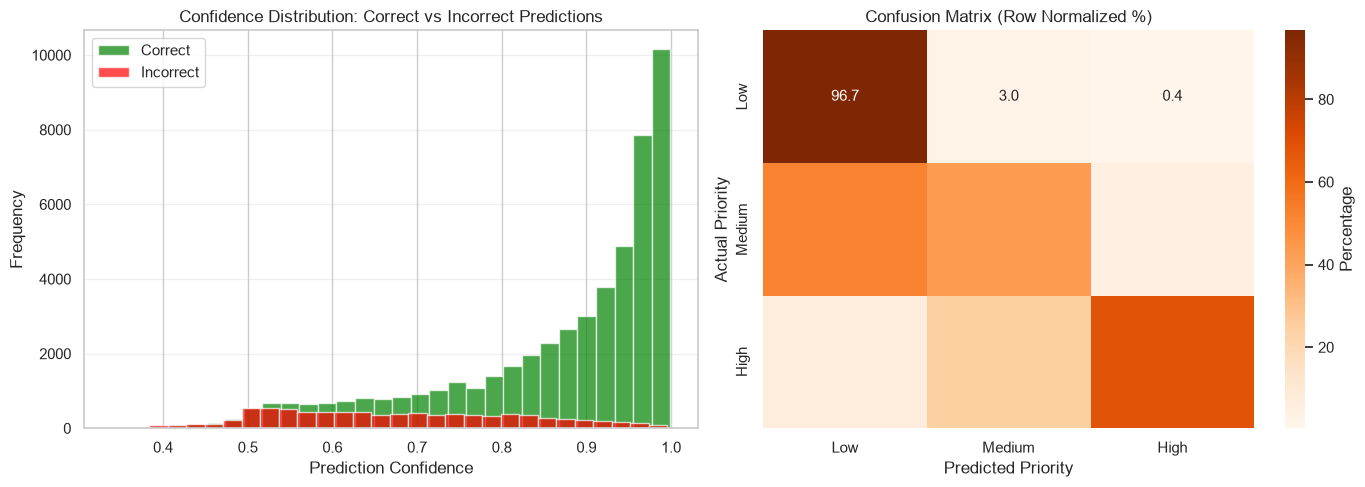


SPATIAL ERROR ANALYSIS
Error Density: 14.55%


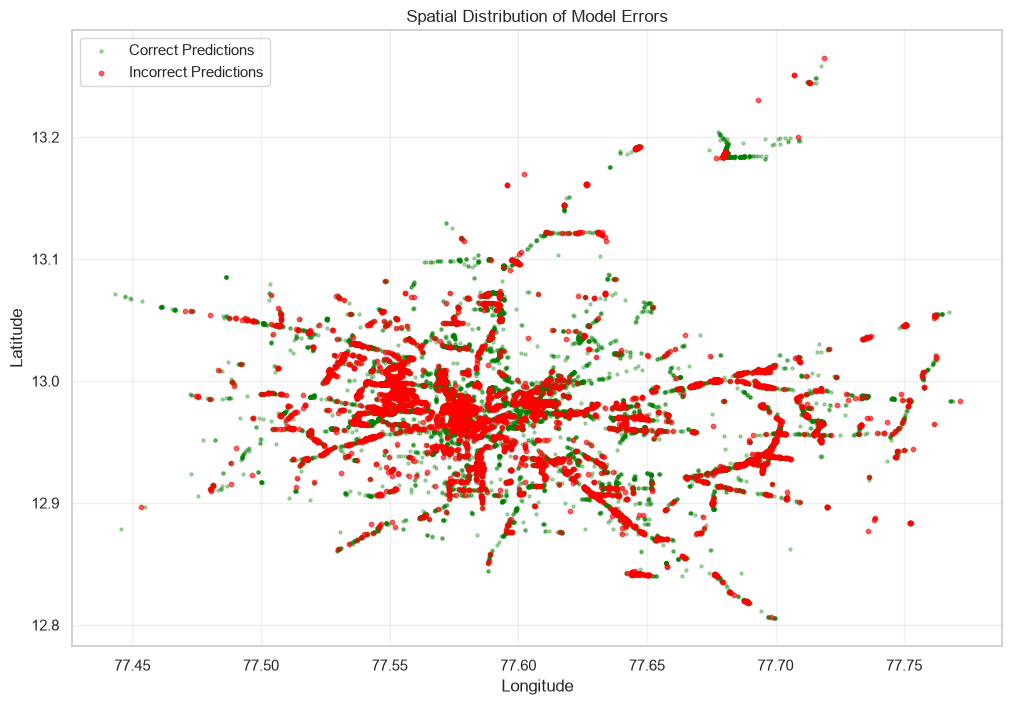

In [ ]:
# Error Analysis: Analyzing Model Mistakes
print("🔍 Analyzing Model Failure Cases...\n")

# Get predictions on test set
y_pred_test_full = model_m3.predict(X_test_m3)
y_prob_test_full = model_m3.predict_proba(X_test_m3)

# Identify misclassified samples
misclassified_mask = y_pred_test_full != y_test_m3
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total Test Samples: {len(y_test_m3)}")
print(f"Misclassified Samples: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test_m3)*100:.2f}%)")

# Analyze confusion by class
print("\n" + "="*60)
print("CONFUSION BY PRIORITY CLASS")
print("="*60)
for true_class in [0, 1, 2]:
    class_name = ['Low', 'Medium', 'High'][true_class]
    class_mask = y_test_m3 == true_class
    class_total = class_mask.sum()
    class_misclassified = (class_mask & misclassified_mask).sum()
    class_accuracy = (class_mask & ~misclassified_mask).sum() / class_total if class_total > 0 else 0
    
    print(f"{class_name:10s}: {class_accuracy:.4f} accuracy ({class_misclassified}/{class_total} misclassified)")

# Analyze confidence scores for correct vs incorrect predictions
correct_mask = ~misclassified_mask
correct_confidence = y_prob_test_full[correct_mask].max(axis=1)
incorrect_confidence = y_prob_test_full[misclassified_mask].max(axis=1)

print("\n" + "="*60)
print("CONFIDENCE SCORE ANALYSIS")
print("="*60)
print(f"Correct Predictions - Mean Confidence: {correct_confidence.mean():.4f}")
print(f"Incorrect Predictions - Mean Confidence: {incorrect_confidence.mean():.4f}")
print(f"Confidence Gap: {correct_confidence.mean() - incorrect_confidence.mean():.4f}")

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence distribution
axes[0].hist(correct_confidence, bins=30, alpha=0.7, label='Correct', color='green')
axes[0].hist(incorrect_confidence, bins=30, alpha=0.7, label='Incorrect', color='red')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Confidence Distribution: Correct vs Incorrect Predictions')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Confusion matrix with percentages
cm_m3_detailed = confusion_matrix(y_test_m3, y_pred_test_full)
cm_percent = cm_m3_detailed.astype('float') / cm_m3_detailed.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1], 
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'],
            cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Row Normalized %)')
axes[1].set_xlabel('Predicted Priority')
axes[1].set_ylabel('Actual Priority')

plt.tight_layout()
plt.show()

# Analyze spatial distribution of errors
print("\n" + "="*60)
print("SPATIAL ERROR ANALYSIS")
print("="*60)

# Get test set coordinates
test_coords = X_test_m3[['latitude', 'longitude']].values
error_coords = test_coords[misclassified_mask]
correct_coords = test_coords[correct_mask]

print(f"Error Density: {len(error_coords) / len(test_coords) * 100:.2f}%")

plt.figure(figsize=(12, 8))
plt.scatter(correct_coords[:, 1], correct_coords[:, 0], c='green', s=5, alpha=0.3, label='Correct Predictions')
plt.scatter(error_coords[:, 1], error_coords[:, 0], c='red', s=10, alpha=0.6, label='Incorrect Predictions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution of Model Errors')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Model Export for Production Deployment

Export the trained models for deployment via FastAPI on Render.

In [30]:
# Export models for production deployment
import joblib

print("📦 Exporting production models...")

# Export Model 1 (Report Validator)
joblib.dump(model_m1_ssl, 'model_report_validator.joblib')
print("✅ Model 1 exported: model_report_validator.joblib")

# Export Model 3 (Congestion Priority Predictor)
joblib.dump(model_m3, 'model_congestion_prioritizer.joblib')
print("✅ Model 3 exported: model_congestion_prioritizer.joblib")

# Export feature lists for reference
import json
with open('ambient_features.json', 'w') as f:
    json.dump(ambient_features, f)
print("✅ Ambient features list exported: ambient_features.json")

print("\n🚀 All models exported successfully! Ready for FastAPI deployment.")

📦 Exporting production models...
✅ Model 1 exported: model_report_validator.joblib
✅ Model 3 exported: model_congestion_prioritizer.joblib
✅ Ambient features list exported: ambient_features.json

🚀 All models exported successfully! Ready for FastAPI deployment.


In [ ]:
# Real-Time Inference Demonstration
def prioritize_new_report(latitude, longitude, vehicle_type, violation_list, created_time_str, junction_name='No Junction'):
    """
    Simulates priority and validation status prediction for a newly received violation report.
    """
    # 1. Parse time
    dt = pd.to_datetime(created_time_str)
    hour = dt.hour
    
    # 2. Compute CIS factors
    v_weight = vehicle_weights.get(vehicle_type.upper(), 1.0)
    j_factor = 1.5 if junction_name != 'No Junction' else 1.0
    s_factor = get_violation_severity(violation_list)
    p_mult = get_peak_multiplier(hour)
    
    cis = v_weight * j_factor * s_factor * p_mult
    
    # Priority
    priority = 'LOW'
    if cis >= 6.0: priority = 'HIGH'
    elif cis >= 2.0: priority = 'MEDIUM'
    
    # Print Actionable Dispatch Ticket
    print("="*40)
    print("   AI DISPATCH PRIORITIZATION TICKET")
    print("="*40)
    print(f"Report Location: [{latitude}, {longitude}] ({junction_name})")
    print(f"Time of Report:  {created_time_str} (Peak multiplier: {p_mult}x)")
    print(f"Vehicle Type:    {vehicle_type} (Weight: {v_weight})")
    print(f"Violations:      {violation_list} (Severity: {s_factor})")
    print("-"*40)
    print(f"Computed Congestion Score: {cis:.2f}")
    print(f"RECOMMENDED DISPATCH PRIORITY: {priority}")
    print("="*40)

# Simulate a new high-priority report (Bus parked near Safina Plaza at 5:30 PM)
prioritize_new_report(
    latitude=12.9782, 
    longitude=77.6011, 
    vehicle_type='PRIVATE BUS', 
    violation_list=['PARKING IN A MAIN ROAD', 'WRONG PARKING'], 
    created_time_str='2026-06-16 17:30:00',
    junction_name='BTP051 - Safina Plaza Junction'
)

# Simulate a low-priority report (Scooter wrong parking at 11:30 PM)
prioritize_new_report(
    latitude=12.9255, 
    longitude=77.6186, 
    vehicle_type='SCOOTER', 
    violation_list=['WRONG PARKING'], 
    created_time_str='2026-06-16 23:30:00'
)

   AI DISPATCH PRIORITIZATION TICKET
Report Location: [12.9782, 77.6011] (BTP051 - Safina Plaza Junction)
Time of Report:  2026-06-16 17:30:00 (Peak multiplier: 2.0x)
Vehicle Type:    PRIVATE BUS (Weight: 4.0)
Violations:      ['PARKING IN A MAIN ROAD', 'WRONG PARKING'] (Severity: 2.0)
----------------------------------------
Computed Congestion Score: 24.00
RECOMMENDED DISPATCH PRIORITY: HIGH
   AI DISPATCH PRIORITIZATION TICKET
Report Location: [12.9255, 77.6186] (No Junction)
Time of Report:  2026-06-16 23:30:00 (Peak multiplier: 0.5x)
Vehicle Type:    SCOOTER (Weight: 0.5)
Violations:      ['WRONG PARKING'] (Severity: 1.5)
----------------------------------------
Computed Congestion Score: 0.38
RECOMMENDED DISPATCH PRIORITY: LOW
